# Stage 6 — secondary analyses and verification

Companion to `pipeline/stage6_evaluation.py`. Re-runs every Stage 6 verification check and the pre-specified secondary analyses, top to bottom, on the laptop (CPU), no manual steps.

Rules I hold this notebook to:

- **No re-implementation.** All methodology logic (loading/joining, the review-count filter, boundaries, queen adjacency, k-means blocks, fold construction, the fold validator, rung definitions, the ridge pipeline) is imported from `pipeline.stage6_evaluation` (`s6`). The only new code is thin glue that keeps the per-tract/per-fold detail the stage discards after pooling — and each helper is verified against the stage's own output to machine precision before I use it.
- **One set of folds.** The spatial folds (primary threshold: minimum 20 reviews per tract via Stage 5's stored `meets_min_reviews` flag; k-means with 10 blocks on tract centroids in EPSG:5070; one-ring queen-contiguity buffer) are built once at the top, validated, and reused for everything below. `RANDOM_STATE = 0` throughout.
- **Primary artefacts untouched.** Nothing here modifies `ladder_results.csv`, `tract_features_2018.parquet` or `figures/stage6_ladder.png` — checked by mtime in the final cell. New tables go to `data/processed/secondary/*.csv`; new figures to `figures/secondary_*.png`.
- **Numbers only.** Tables report every cell, unfiltered; interpretation belongs in the write-up.

Contents: §1 primary ladder verification (Checks 1–5) · §2 per-metro breakdown and block purity (Check 6) · §3 pre-specified secondary analyses (3a solo designs, 3b feature weights, 3c aspect ablation) · additional review-subsampling curve (post-hoc) · §4 threshold sensitivity (read-only) · §5 exploratory extras · manifest.

Run: `.venv\Scripts\python.exe -m nbconvert --to notebook --execute --inplace notebooks/stage6_secondary_analyses.ipynb`

In [1]:
# Locate the project root (the directory holding config.py) whether the notebook is
# executed from notebooks/ (jupyter / nbconvert default) or from the repository root.
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
while not (ROOT / "config.py").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("could not find the project root (config.py) above the cwd")
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import platform

import numpy as np
import pandas as pd
import sklearn
from IPython.display import Image, display
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score

import config
import pipeline.stage6_evaluation as s6  # single source of truth — nothing re-implemented here

import matplotlib  # s6 selects the Agg backend on import; pyplot follows it
import matplotlib.pyplot as plt

RANDOM_STATE = s6.RANDOM_STATE  # 0 — every stochastic step below inherits this
assert RANDOM_STATE == 0
assert len(config.ACS_YEARS) == 1, "notebook is single-vintage, like Stage 6"
ACS_YEAR = config.ACS_YEARS[0]

SECONDARY_DIR = config.PROCESSED_DIR / "secondary"
SECONDARY_DIR.mkdir(parents=True, exist_ok=True)

# Primary artefacts this notebook must never touch — mtimes re-checked in the final cell.
PRIMARY_ARTEFACTS = [
    config.PROCESSED_DIR / "ladder_results.csv",
    config.PROCESSED_DIR / f"tract_features_{ACS_YEAR}.parquet",
    config.FIGURES_DIR / "stage6_ladder.png",
]
_primary_mtimes = {p: p.stat().st_mtime_ns for p in PRIMARY_ARTEFACTS}

WRITTEN = []  # manifest of every file this notebook writes


def save_csv(df, name):
    path = SECONDARY_DIR / name
    df.to_csv(path, index=False)
    WRITTEN.append(path)
    print(f"table  -> {path.relative_to(config.PROJECT_ROOT)}")
    return path


def save_fig(fig, name):
    path = config.FIGURES_DIR / name
    fig.savefig(path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    WRITTEN.append(path)
    print(f"figure -> {path.relative_to(config.PROJECT_ROOT)}")
    display(Image(str(path)))
    return path


BLUE = "#1f77b4"  # the project's primary mark colour (matches figures/stage6_ladder.png)

pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.precision", 6)

print(f"python {platform.python_version()} | numpy {np.__version__} | pandas {pd.__version__} | "
      f"scikit-learn {sklearn.__version__} | matplotlib {matplotlib.__version__}")
print(f"project root: {ROOT}")

python 3.13.5 | numpy 2.4.6 | pandas 3.0.3 | scikit-learn 1.9.0 | matplotlib 3.10.9
project root: C:\Users\joein\OneDrive\one drive\QMUL\Dissertation\Code


## Shared spatial folds (built once, reused everywhere)

I rebuild the primary analysis frame and CV folds with the stage's own functions: `load_joined` joins Stage 5 features to ACS outcomes, `apply_min_reviews` applies the primary floor via the stored `meets_min_reviews` flag (≥ 20 reviews), `load_tract_boundaries` loads the cached polygons, `queen_neighbours` builds queen adjacency, `assign_blocks` assigns k-means blocks on EPSG:5070 centroids (k = 10, seed 0), and `build_folds` constructs the leave-one-block-out folds with the one-ring queen buffer. The stage's own `validate_folds` then asserts the blocks partition the tracts and that zero training tracts are queen-adjacent to any held-out tract. Every analysis below uses these folds.

In [2]:
merged = s6.load_joined(ACS_YEAR, smoke=False)
analysis = s6.apply_min_reviews(merged)  # no override -> Stage 5's stored meets_min_reviews flag (primary)
analysis_ids = analysis["tract_geoid"].tolist()

tracts = s6.load_tract_boundaries(ACS_YEAR)  # cached parquet — no network after the first Stage 6 run
tracts_analysis = tracts[tracts["tract_geoid"].isin(analysis_ids)].reset_index(drop=True)
missing_geom = set(analysis_ids) - set(tracts_analysis["tract_geoid"])
assert not missing_geom, f"{len(missing_geom)} analysis tracts lack a boundary polygon"

neighbours = s6.queen_neighbours(tracts_analysis)
block_of = s6.assign_blocks(tracts_analysis)  # k-means (k=10) on EPSG:5070 centroids, random_state=0
folds = s6.build_folds(analysis_ids, block_of, neighbours)  # leave-one-block-out + one-ring queen buffer
s6.validate_folds(folds, neighbours, analysis_ids)  # asserts zero train/test queen adjacency

# Feature sets, taken verbatim from the stage's rung definitions.
RUNG_COLS = {name: cols for _, name, cols in s6.rung_specs()}
COUNTS_COLS = s6.usable_columns(analysis, RUNG_COLS["counts"])
STARS_COLS = s6.usable_columns(analysis, RUNG_COLS["stars"])
VADER_COLS = s6.usable_columns(analysis, RUNG_COLS["vader"])
SIEBERT_COLS = s6.usable_columns(analysis, RUNG_COLS["siebert"])
ABSA_COLS = s6.usable_columns(analysis, RUNG_COLS["absa"])
FULL_COLS = COUNTS_COLS + STARS_COLS + VADER_COLS + SIEBERT_COLS + ABSA_COLS
assert len(FULL_COLS) == 16, FULL_COLS
print(f"\nfull rung-6 feature set ({len(FULL_COLS)} features): {FULL_COLS}")

[1] Load + join (ACS 2018)
    ACS tracts (outcome table)            : 28,931
    tracts with >= 1 windowed review      : 3,810
    joined (have both feature & outcome)  : 3,810
    meets_min_reviews (>= 20 reviews) : 3,444 kept, 366 excluded (too noisy)
    per-target tracts with a non-null outcome:
      Median household income   : 3,418
      Poverty rate              : 3,425
      Unemployment rate         : 3,425
      Median gross rent         : 3,358



[5] Spatial-fold validation
    10 spatial blocks partition 3444 tracts (test sizes 46-1274, median 244)
    train/test queen-adjacency violations : 0  [PASS]
    mean train size (after buffer)        : 3099
    mean buffer size (dropped per fold)   : 0

full rung-6 feature set (16 features): ['log_n_reviews', 'log_n_businesses', 'stars_mean', 'vader_mean', 'siebert_share_pos', 'siebert_mean_prob', 'food_mention_rate', 'food_polarity_mean', 'service_mention_rate', 'service_polarity_mean', 'price_mention_rate', 'price_polarity_mean', 'ambience_mention_rate', 'ambience_polarity_mean', 'location_mention_rate', 'location_polarity_mean']


## Section 1 — Primary ladder verification (Checks 1–5)

I recompute the full nested ladder (naive → +counts → +stars → +VADER → +SiEBERT → +ABSA, plus the RandomForest full-feature robustness row) with `s6.run_ladder` on the shared folds, then assert every row's pooled out-of-sample R² and RMSE match the primary artefact `data/processed/ladder_results.csv` to machine precision — I check the ladder reproduces before trusting anything downstream. Checks 1–5 follow as separate tables, each saved to `data/processed/secondary/`.

Pooled statistic: R²/RMSE pool the held-out predictions across the ten folds — each tract is predicted exactly once, by the fold that holds its block out — and score the concatenated vector once. A concatenation of held-out predictions, not a mean of per-fold R² values.

In [3]:
results = s6.run_ladder(analysis, folds)  # the full ladder + RF row, on the shared folds

primary = pd.read_csv(s6.results_csv(smoke=False))
key = ["target", "rung", "predictor"]
cmp = results.merge(primary, on=key, suffixes=("_nb", "_csv"), validate="1:1")
assert len(cmp) == len(results) == len(primary) == 28  # (6 rungs + RF) x 4 targets
assert (cmp["n_test_tracts_nb"] == cmp["n_test_tracts_csv"]).all()
assert np.allclose(cmp["r2_nb"], cmp["r2_csv"], rtol=1e-10, atol=1e-12)
assert np.allclose(cmp["rmse_nb"], cmp["rmse_csv"], rtol=1e-10, atol=1e-12)
print("\nVERIFIED: recomputed ladder matches data/processed/ladder_results.csv to machine precision")
print(f"  max |dR2|   = {np.abs(cmp['r2_nb'] - cmp['r2_csv']).max():.3e}")
print(f"  max |dRMSE| = {np.abs(cmp['rmse_nb'] - cmp['rmse_csv']).max():.3e}")

ridge = results[results["predictor"] == "ridge"].copy()  # reused throughout the notebook


[4] Ladder - Median household income


    1. naive    R2 -0.076  dR2   n/a  vs-naive +0.000  RMSE     32,432  (n=3418, 10 folds)


    2. counts   R2 -0.076  dR2 -0.000  vs-naive -0.000  RMSE     32,438  (n=3418, 10 folds)


    3. stars    R2 -0.081  dR2 -0.004  vs-naive -0.005  RMSE     32,504  (n=3418, 10 folds)


    4. vader    R2 -0.051  dR2 +0.029  vs-naive +0.025  RMSE     32,058  (n=3418, 10 folds)


...

    3. stars    R2 -0.055  dR2 -0.004  vs-naive -0.001  RMSE        361  (n=3358, 10 folds)


    4. vader    R2 -0.056  dR2 -0.001  vs-naive -0.002  RMSE        362  (n=3358, 10 folds)


    5. siebert  R2 -0.033  dR2 +0.023  vs-naive +0.020  RMSE        358  (n=3358, 10 folds)


    6. absa     R2 +0.008  dR2 +0.041  vs-naive +0.061  RMSE        351  (n=3358, 10 folds)


    RF (all 16 features)     : R2 -0.018  (ridge final rung R2 +0.008; delta -0.026)

VERIFIED: recomputed ladder matches data/processed/ladder_results.csv to machine precision
  max |dR2|   = 9.714e-17
  max |dRMSE| = 3.638e-12


### Check 1 — naive floor per target

Rung-1 baseline: predict the training-fold mean. Slightly negative pooled R² is the expected signature of spatial CV — fold means differ from the held-out block's mean.

In [4]:
naive_floor = (ridge[ridge["rung"] == 1]
               [["target", "target_label", "r2", "rmse", "n_test_tracts", "n_folds"]]
               .rename(columns={"r2": "naive_r2", "rmse": "naive_rmse"})
               .reset_index(drop=True))
save_csv(naive_floor, "sec1_check1_naive_floor.csv")
naive_floor

table  -> data\processed\secondary\sec1_check1_naive_floor.csv


,target,target_label,naive_r2,naive_rmse,n_test_tracts,n_folds
0,median_household_income,Median household income,-0.075811,32432.110664,3418,10
1,poverty_rate,Poverty rate,-0.017041,0.123644,3425,10
2,unemployment_rate,Unemployment rate,-0.006645,0.048267,3425,10
3,median_gross_rent,Median gross rent,-0.053686,361.235048,3358,10


### Check 2 — full ladder (R² + RMSE, every target × rung, plus the RandomForest row)

For the RF row (`rung` 7), `r2_increment` is against the final ridge rung (6), not a preceding rung.

In [5]:
full_ladder = results[["target_label", "rung", "rung_name", "predictor", "status",
                       "n_features", "n_test_tracts", "n_folds", "r2", "rmse",
                       "r2_increment", "rmse_increment", "r2_vs_naive"]].reset_index(drop=True)
save_csv(full_ladder, "sec1_check2_full_ladder.csv")
full_ladder

table  -> data\processed\secondary\sec1_check2_full_ladder.csv


,target_label,rung,rung_name,predictor,status,n_features,n_test_tracts,n_folds,r2,rmse,r2_increment,rmse_increment,r2_vs_naive
0,Median household income,1,naive,ridge,ok,0,3418,10,-0.075811,32432.110664,NaN,NaN,0.000000
1,Median household income,2,counts,ridge,ok,2,3418,10,-0.076213,32438.174977,-0.000402,6.064312,-0.000402
2,Median household income,3,stars,ridge,ok,3,3418,10,-0.080596,32504.162707,-0.004383,65.987731,-0.004785
3,Median household income,4,vader,ridge,ok,4,3418,10,-0.051107,32057.587130,0.029489,-446.575578,0.024703
4,Median household income,5,siebert,ridge,ok,6,3418,10,-0.020797,31591.988361,0.030310,-465.598769,0.055014
5,Median household income,6,absa,ridge,ok,16,3418,10,0.063446,30260.326278,0.084243,-1331.662084,0.139257
6,Median household income,7,tree_full,random_forest,robustness,16,3418,10,0.044542,30564.199408,-0.018904,303.873130,0.120353
7,Poverty rate,1,naive,ridge,ok,0,3425,10,-0.017041,0.123644,NaN,NaN,0.000000
8,Poverty rate,2,counts,ridge,ok,2,3425,10,-0.004107,0.122855,0.012934,-0.000789,0.012934
9,Poverty rate,3,stars,ridge,ok,3,3425,10,-0.004416,0.122874,-0.000310,0.000019,0.012625


### Check 3 — text-over-stars deltas

The novelty test: R²(rung) − R²(stars, rung 3) for each text rung (4 VADER, 5 SiEBERT, 6 ABSA), per target.

In [6]:
rows = []
for target, label, _ in s6.TARGETS:
    sub = ridge[ridge["target"] == target].set_index("rung")
    for rung in (4, 5, 6):
        rows.append({
            "target_label": label, "rung": rung, "rung_name": sub.loc[rung, "rung_name"],
            "r2": sub.loc[rung, "r2"], "stars_r2": sub.loc[3, "r2"],
            "delta_over_stars": sub.loc[rung, "r2"] - sub.loc[3, "r2"],
        })
text_over_stars = pd.DataFrame(rows)
save_csv(text_over_stars, "sec1_check3_text_over_stars.csv")
text_over_stars

table  -> data\processed\secondary\sec1_check3_text_over_stars.csv


,target_label,rung,rung_name,r2,stars_r2,delta_over_stars
0,Median household income,4,vader,-0.051107,-0.080596,0.029489
1,Median household income,5,siebert,-0.020797,-0.080596,0.059799
2,Median household income,6,absa,0.063446,-0.080596,0.144042
3,Poverty rate,4,vader,0.025475,-0.004416,0.029891
4,Poverty rate,5,siebert,0.056357,-0.004416,0.060773
5,Poverty rate,6,absa,0.133527,-0.004416,0.137943
6,Unemployment rate,4,vader,0.062777,0.042134,0.020643
7,Unemployment rate,5,siebert,0.069200,0.042134,0.027066
8,Unemployment rate,6,absa,0.103554,0.042134,0.061420
9,Median gross rent,4,vader,-0.055951,-0.054552,-0.001399


### Check 4 — per-target analysis n

Tract counts after the two exclusions: below the 20-review floor (target-independent), then NaN on the specific outcome. `n_analysis` is asserted equal to the ladder's `n_test_tracts` — every analysis tract is held out exactly once.

In [7]:
rows = []
for target, label, _ in s6.TARGETS:
    n_analysis = int(analysis[target].notna().sum())
    n_rung6 = int(ridge.loc[(ridge["target"] == target) & (ridge["rung"] == 6),
                            "n_test_tracts"].iloc[0])
    assert n_analysis == n_rung6, (target, n_analysis, n_rung6)
    rows.append({
        "target_label": label,
        "n_tracts_joined": len(merged),
        "n_after_min_reviews": len(analysis),
        "n_nan_outcome": int(analysis[target].isna().sum()),
        "n_analysis": n_analysis,
    })
analysis_n = pd.DataFrame(rows)
save_csv(analysis_n, "sec1_check4_analysis_n.csv")
analysis_n

table  -> data\processed\secondary\sec1_check4_analysis_n.csv


,target_label,n_tracts_joined,n_after_min_reviews,n_nan_outcome,n_analysis
0,Median household income,3810,3444,26,3418
1,Poverty rate,3810,3444,19,3425
2,Unemployment rate,3810,3444,19,3425
3,Median gross rent,3810,3444,86,3358


### Check 5 — RandomForest − ridge-ABSA delta per target

The non-linear robustness check: pooled OOS R² of the RandomForest on the full 16-feature set, minus the ridge rung-6 value, same folds.

In [8]:
rf = results[results["predictor"] == "random_forest"].set_index("target")
r6 = ridge[ridge["rung"] == 6].set_index("target")
rf_vs_ridge = pd.DataFrame({
    "target_label": r6["target_label"],
    "ridge_absa_r2": r6["r2"],
    "rf_r2": rf["r2"],
    "rf_minus_ridge_absa": rf["r2"] - r6["r2"],
}).reset_index()
save_csv(rf_vs_ridge, "sec1_check5_rf_vs_ridge.csv")
rf_vs_ridge

table  -> data\processed\secondary\sec1_check5_rf_vs_ridge.csv


,target,target_label,ridge_absa_r2,rf_r2,rf_minus_ridge_absa
0,median_household_income,Median household income,0.063446,0.044542,-0.018904
1,poverty_rate,Poverty rate,0.133527,0.115994,-0.017534
2,unemployment_rate,Unemployment rate,0.103554,0.091350,-0.012204
3,median_gross_rent,Median gross rent,0.007596,-0.018348,-0.025944


## Section 2 — Per-metro breakdown and block purity (Check 6)

### (a) Tract → metro assignment

I map the state-FIPS prefix of the tract GEOID to a metro, merging the multi-state metros per the study design (Philadelphia = PA + NJ + DE; St Louis = MO + IL) — 10 metro groups from the 13 study states. Why this method: the project defines geography at the state level (`config.STATES`) precisely because these metros straddle state lines; the mapping is deterministic from the tract identifier alone — no auxiliary join, no modal-vote ambiguity from business-level `city` strings; and it follows the project convention of reading state from the GEOID FIPS prefix, never from the Yelp `state` label.

Limitations: every in-state tract is attributed to that state's named metro, so a reviewed tract lying elsewhere in the state would be mislabelled; and the PA/NJ/DE and MO/IL merges are by construction, not by distance. Stage 1 keeps only businesses inside the study states and Yelp coverage clusters in a single metro per state, so these are edge cases; the block-purity table in (b) quantifies how well the spatial blocks align with metros under this mapping.

In [9]:
# State FIPS (tract GEOID prefix) -> metro. Multi-state metros merged per the study design.
FIPS_TO_METRO = {
    "42": "Philadelphia", "34": "Philadelphia", "10": "Philadelphia",
    "29": "St Louis", "17": "St Louis",
    "12": "Tampa",
    "47": "Nashville",
    "18": "Indianapolis",
    "22": "New Orleans",
    "04": "Tucson",
    "32": "Reno",
    "06": "Santa Barbara",
    "16": "Boise",
}
assert set(FIPS_TO_METRO) == {fips for fips, _ in config.STATES}, "map out of sync with config.STATES"

analysis_metro = analysis[["tract_geoid"]].copy()
analysis_metro["metro"] = analysis_metro["tract_geoid"].str[:2].map(FIPS_TO_METRO)
analysis_metro["block"] = analysis_metro["tract_geoid"].map(block_of)
assert analysis_metro["metro"].notna().all()
assert analysis_metro["block"].notna().all()

metro_counts = (analysis_metro["metro"].value_counts().rename_axis("metro")
                .reset_index(name="n_tracts").sort_values("metro").reset_index(drop=True))
save_csv(metro_counts, "sec2_metro_tract_counts.csv")
metro_counts

table  -> data\processed\secondary\sec2_metro_tract_counts.csv

,metro,n_tracts
0,Boise,57
1,Indianapolis,260
2,Nashville,228
3,New Orleans,267
4,Philadelphia,1274
5,Reno,100
6,Santa Barbara,47
7,St Louis,365
8,Tampa,643
9,Tucson,203


### (b) k-means-block → metro purity

For each of the 10 spatial blocks: its majority metro under the mapping above, the share of its tracts in that metro (purity), and its size.

In [10]:
rows = []
for block, grp in analysis_metro.groupby("block"):
    counts = grp["metro"].value_counts()
    rows.append({
        "block": int(block), "n_tracts": len(grp),
        "majority_metro": counts.index[0],
        "purity": counts.iloc[0] / len(grp),
        "n_metros_present": len(counts),
    })
block_purity = pd.DataFrame(rows).sort_values("block").reset_index(drop=True)
save_csv(block_purity, "sec2_block_metro_purity.csv")
block_purity

table  -> data\processed\secondary\sec2_block_metro_purity.csv


,block,n_tracts,majority_metro,purity,n_metros_present
0,0,260,Indianapolis,1.000000,1
1,1,203,Tucson,1.000000,1
2,2,643,Tampa,1.000000,1
3,3,1274,Philadelphia,1.000000,1
4,4,57,Boise,1.000000,1
5,5,365,St Louis,1.000000,1
6,6,267,New Orleans,1.000000,1
7,7,101,Reno,0.990099,2
8,8,228,Nashville,1.000000,1
9,9,46,Santa Barbara,1.000000,1


### Per-tract held-out predictions (verified helper)

`s6.spatial_cv` returns pooled statistics only, so the per-metro breakdown needs a thin wrapper that runs the identical fold protocol (same NaN-target filtering, same `s6.MIN_TRAIN_TRACTS` skip rule, same fresh-estimator factory, same naive-mean fallback) but keeps each tract's held-out prediction. The assert checks the wrapper against the stage: pooled R² recomputed from its per-tract predictions must equal the primary rung-6 value to machine precision, on every target.

In [11]:
def oos_predictions(frame, feature_cols, target, folds, make_estimator):
    """Per-tract held-out predictions under exactly the fold protocol of s6.spatial_cv."""
    fi = frame.set_index("tract_geoid")
    rows = []
    for fold in folds:
        tr = [t for t in fold["train"] if pd.notna(fi.at[t, target])]
        te = [t for t in fold["test"] if pd.notna(fi.at[t, target])]
        if len(te) == 0 or len(tr) < s6.MIN_TRAIN_TRACTS:
            continue
        ytr = fi.loc[tr, target].to_numpy(dtype=float)
        if feature_cols:
            est = make_estimator()
            est.fit(fi.loc[tr, feature_cols].to_numpy(dtype=float), ytr)
            pred = est.predict(fi.loc[te, feature_cols].to_numpy(dtype=float))
        else:
            pred = np.full(len(te), ytr.mean())
        yte = fi.loc[te, target].to_numpy(dtype=float)
        for t, y_t, y_p in zip(te, yte, np.asarray(pred, dtype=float)):
            rows.append({"tract_geoid": t, "block": fold["block"], "y_true": y_t, "y_pred": y_p})
    return pd.DataFrame(rows)


absa_preds = {}
for target, label, _ in s6.TARGETS:
    preds = oos_predictions(analysis, FULL_COLS, target, folds, s6.ridge_pipeline)
    pooled = r2_score(preds["y_true"], preds["y_pred"])
    ref = float(ridge.loc[(ridge["target"] == target) & (ridge["rung"] == 6), "r2"].iloc[0])
    assert np.isclose(pooled, ref, rtol=1e-10, atol=1e-12), (target, pooled, ref)
    absa_preds[target] = preds
print("helper verified: pooled R2 from per-tract predictions matches the primary rung-6 value on every target")

helper verified: pooled R2 from per-tract predictions matches the primary rung-6 value on every target


### (c) ABSA rung (rung 6) — per-metro and per-fold breakdown

The pooled OOS predictions of the headline ABSA rung, broken out by metro (R², RMSE, n) and by fold/block (R², n). A subset's R² uses that subset's own outcome variance as the denominator — a within-subset statistic that can be strongly negative on small or homogeneous subsets; `small_sample` flags metros with fewer than 50 analysis tracts, where R² is unstable.

In [12]:
SMALL_N = 50  # metros below this many tracts get a small-sample flag

metro_rows, fold_rows = [], []
for target, label, _ in s6.TARGETS:
    p = absa_preds[target].merge(analysis_metro[["tract_geoid", "metro"]],
                                 on="tract_geoid", validate="1:1")
    for metro, g in p.groupby("metro"):
        scorable = len(g) >= 2 and float(np.var(g["y_true"])) > 0
        metro_rows.append({
            "target_label": label, "metro": metro, "n_tracts": len(g),
            "small_sample": len(g) < SMALL_N,
            "r2": r2_score(g["y_true"], g["y_pred"]) if scorable else np.nan,
            "rmse": float(np.sqrt(np.mean((g["y_true"] - g["y_pred"]) ** 2))),
        })
    for block, g in absa_preds[target].groupby("block"):
        scorable = len(g) >= 2 and float(np.var(g["y_true"])) > 0
        fold_rows.append({
            "target_label": label, "block": int(block), "n_tracts": len(g),
            "r2": r2_score(g["y_true"], g["y_pred"]) if scorable else np.nan,
        })

absa_per_metro = (pd.DataFrame(metro_rows)
                  .sort_values(["target_label", "metro"]).reset_index(drop=True))
absa_per_fold = (pd.DataFrame(fold_rows)
                 .sort_values(["target_label", "block"]).reset_index(drop=True))
save_csv(absa_per_metro, "sec2_absa_per_metro.csv")
save_csv(absa_per_fold, "sec2_absa_per_fold_r2.csv")
display(absa_per_metro)
absa_per_fold

table  -> data\processed\secondary\sec2_absa_per_metro.csv
table  -> data\processed\secondary\sec2_absa_per_fold_r2.csv


,target_label,metro,n_tracts,small_sample,r2,rmse
0,Median gross rent,Boise,57,False,-0.946316,281.402929
1,Median gross rent,Indianapolis,254,False,-0.365739,255.883862
2,Median gross rent,Nashville,221,False,0.122889,378.137421
3,Median gross rent,New Orleans,263,False,-0.230610,241.494521
4,Median gross rent,Philadelphia,1226,False,-0.123078,386.181297
5,Median gross rent,Reno,96,False,0.019346,363.777552
6,Median gross rent,Santa Barbara,46,True,-3.359675,832.623725
7,Median gross rent,St Louis,362,False,-0.511714,311.568797
8,Median gross rent,Tampa,633,False,0.051372,299.838518
9,Median gross rent,Tucson,200,False,-0.368681,354.507409


,target_label,block,n_tracts,r2
0,Median gross rent,0,254,-0.365739
1,Median gross rent,1,200,-0.368681
2,Median gross rent,2,633,0.051372
3,Median gross rent,3,1226,-0.123078
4,Median gross rent,4,57,-0.946316
5,Median gross rent,5,362,-0.511714
6,Median gross rent,6,263,-0.230610
7,Median gross rent,7,97,0.015581
8,Median gross rent,8,221,0.122889
9,Median gross rent,9,45,-3.259710


## Section 3 — Pre-specified secondary analyses

A fixed list, decided before running: 3a solo (marginal-over-stars) designs, 3b feature weights on the full model, 3c per-aspect ablation within the ABSA block. All use the shared folds and the stage's ridge pipeline (`s6.spatial_cv` + `s6.ridge_pipeline`); nothing else varies.

### 3a — Marginal-over-stars ("solo") designs

For each method M ∈ {VADER, SiEBERT, ABSA}: fit counts + stars + M only, not the nested cumulative set. This measures each method's standalone value over the free signals already in the data, complementing the conservative nested increments of the primary ladder, where a later rung only gets credit for what the earlier text rungs did not already capture. The counts+stars baseline is asserted identical to primary rung 3.

In [13]:
solo_specs = [
    ("counts+stars (baseline)", COUNTS_COLS + STARS_COLS),
    ("counts+stars+VADER", COUNTS_COLS + STARS_COLS + VADER_COLS),
    ("counts+stars+SiEBERT", COUNTS_COLS + STARS_COLS + SIEBERT_COLS),
    ("counts+stars+ABSA", COUNTS_COLS + STARS_COLS + ABSA_COLS),
]
rows = []
for target, label, _ in s6.TARGETS:
    res_by_name = {name: s6.spatial_cv(analysis, cols, target, folds, s6.ridge_pipeline)
                   for name, cols in solo_specs}
    base = res_by_name["counts+stars (baseline)"]
    ref3 = float(ridge.loc[(ridge["target"] == target) & (ridge["rung"] == 3), "r2"].iloc[0])
    assert np.isclose(base["r2"], ref3, rtol=1e-10, atol=1e-12)  # baseline == primary rung 3
    for name, cols in solo_specs:
        res = res_by_name[name]
        rows.append({"target_label": label, "model": name, "n_features": len(cols),
                     "r2": res["r2"], "rmse": res["rmse"],
                     "delta_over_counts_stars": res["r2"] - base["r2"]})
solo_tbl = pd.DataFrame(rows)
save_csv(solo_tbl, "sec3a_solo_over_stars.csv")
solo_tbl

table  -> data\processed\secondary\sec3a_solo_over_stars.csv


,target_label,model,n_features,r2,rmse,delta_over_counts_stars
0,Median household income,counts+stars (baseline),3,-0.080596,32504.162707,0.000000
1,Median household income,counts+stars+VADER,4,-0.051107,32057.587130,0.029489
2,Median household income,counts+stars+SiEBERT,5,-0.064638,32263.267019,0.015958
3,Median household income,counts+stars+ABSA,13,0.041734,30609.084299,0.122330
4,Poverty rate,counts+stars (baseline),3,-0.004416,0.122874,0.000000
5,Poverty rate,counts+stars+VADER,4,0.025475,0.121032,0.029891
6,Poverty rate,counts+stars+SiEBERT,5,0.011606,0.121890,0.016022
7,Poverty rate,counts+stars+ABSA,13,0.109482,0.115697,0.113898
8,Unemployment rate,counts+stars (baseline),3,0.042134,0.047083,0.000000
9,Unemployment rate,counts+stars+VADER,4,0.062777,0.046573,0.020643


### 3b — Feature weights on the full 16-feature model

Two views of the same per-fold ridge fits (identical fold protocol, one model per fold): **standardised-feature ridge coefficients** — the pipeline scales features before the ridge step, so coefficients are comparable across features and read as target units per one standard deviation of the feature (the target itself is unscaled); mean ± sd across the 10 folds — and **permutation importance** on the held-out tracts of each fold (drop in held-out R² when a feature is permuted; 10 repeats, seed 0).

Note on permutation-importance magnitudes. The drop in R² is unbounded above: when two features are strongly collinear (here the two SiEBERT columns, and stars/VADER), ridge spreads weight across the pair and permuting one member breaks the cancellation, which can send that fold's held-out R² far below zero — a single fold can then dominate the cross-fold mean. So the table reports the cross-fold mean ± sd and the cross-fold median, and the figure plots the median (robust). This is a property of permutation importance under collinearity, not a computation error.

In [14]:
def fit_folds(frame, feature_cols, target, folds, make_estimator):
    """One fitted estimator per usable fold (identical protocol to s6.spatial_cv);
    returns (block, fitted estimator, test tract ids) triples."""
    fi = frame.set_index("tract_geoid")
    fitted = []
    for fold in folds:
        tr = [t for t in fold["train"] if pd.notna(fi.at[t, target])]
        te = [t for t in fold["test"] if pd.notna(fi.at[t, target])]
        if len(te) == 0 or len(tr) < s6.MIN_TRAIN_TRACTS:
            continue
        est = make_estimator()
        est.fit(fi.loc[tr, feature_cols].to_numpy(dtype=float),
                fi.loc[tr, target].to_numpy(dtype=float))
        fitted.append((fold["block"], est, te))
    return fitted


fi_all = analysis.set_index("tract_geoid")
coef_rows, perm_rows = [], []
for target, label, _ in s6.TARGETS:
    for block, est, te in fit_folds(analysis, FULL_COLS, target, folds, s6.ridge_pipeline):
        for feat, coef in zip(FULL_COLS, est.named_steps["ridge"].coef_):
            coef_rows.append({"target": target, "target_label": label, "block": int(block),
                              "feature": feat, "coef": float(coef)})
        X_te = fi_all.loc[te, FULL_COLS].to_numpy(dtype=float)
        y_te = fi_all.loc[te, target].to_numpy(dtype=float)
        pi = permutation_importance(est, X_te, y_te, n_repeats=10, random_state=RANDOM_STATE)
        for feat, imp in zip(FULL_COLS, pi.importances_mean):
            perm_rows.append({"target": target, "target_label": label, "block": int(block),
                              "feature": feat, "importance": float(imp)})

coef_tbl = (pd.DataFrame(coef_rows)
            .groupby(["target", "target_label", "feature"], as_index=False)["coef"]
            .agg(coef_mean="mean", coef_sd="std"))
perm_tbl = (pd.DataFrame(perm_rows)
            .groupby(["target", "target_label", "feature"], as_index=False)["importance"]
            .agg(importance_mean="mean", importance_sd="std", importance_median="median"))
save_csv(coef_tbl, "sec3b_ridge_coefficients.csv")
save_csv(perm_tbl, "sec3b_permutation_importance.csv")

display(perm_tbl.sort_values(["target_label", "importance_median"],
                             ascending=[True, False]).reset_index(drop=True))
coef_disp = (coef_tbl.assign(_abs=coef_tbl["coef_mean"].abs())
             .sort_values(["target_label", "_abs"], ascending=[True, False])
             .drop(columns="_abs").reset_index(drop=True))
coef_disp

table  -> data\processed\secondary\sec3b_ridge_coefficients.csv
table  -> data\processed\secondary\sec3b_permutation_importance.csv


,target,target_label,feature,importance_mean,importance_sd,importance_median
0,median_gross_rent,Median gross rent,siebert_mean_prob,0.252693,0.140700,0.258077
1,median_gross_rent,Median gross rent,siebert_share_pos,0.242016,0.135813,0.251121
2,median_gross_rent,Median gross rent,stars_mean,0.181063,0.117809,0.134531
3,median_gross_rent,Median gross rent,service_polarity_mean,0.112724,0.066491,0.093992
4,median_gross_rent,Median gross rent,vader_mean,0.091771,0.048982,0.090242
5,median_gross_rent,Median gross rent,food_mention_rate,0.098878,0.084854,0.086822
6,median_gross_rent,Median gross rent,price_polarity_mean,0.048701,0.053627,0.057530
7,median_gross_rent,Median gross rent,log_n_businesses,0.022011,0.021562,0.016032
8,median_gross_rent,Median gross rent,location_polarity_mean,0.010829,0.022321,0.011480
9,median_gross_rent,Median gross rent,ambience_polarity_mean,0.008087,0.017377,0.009094


,target,target_label,feature,coef_mean,coef_sd
0,median_gross_rent,Median gross rent,siebert_mean_prob,-103.700569,13.900150
1,median_gross_rent,Median gross rent,siebert_share_pos,-101.466585,14.035682
2,median_gross_rent,Median gross rent,stars_mean,87.689149,32.321165
3,median_gross_rent,Median gross rent,service_polarity_mean,73.280141,7.960086
4,median_gross_rent,Median gross rent,vader_mean,63.308338,6.113063
5,median_gross_rent,Median gross rent,food_mention_rate,-63.011858,7.394973
6,median_gross_rent,Median gross rent,price_polarity_mean,-60.063569,6.566133
7,median_gross_rent,Median gross rent,log_n_reviews,42.652860,18.137561
8,median_gross_rent,Median gross rent,location_polarity_mean,27.974163,2.113588
9,median_gross_rent,Median gross rent,ambience_polarity_mean,27.205783,3.940123


figure -> figures\secondary_permutation_importance.png


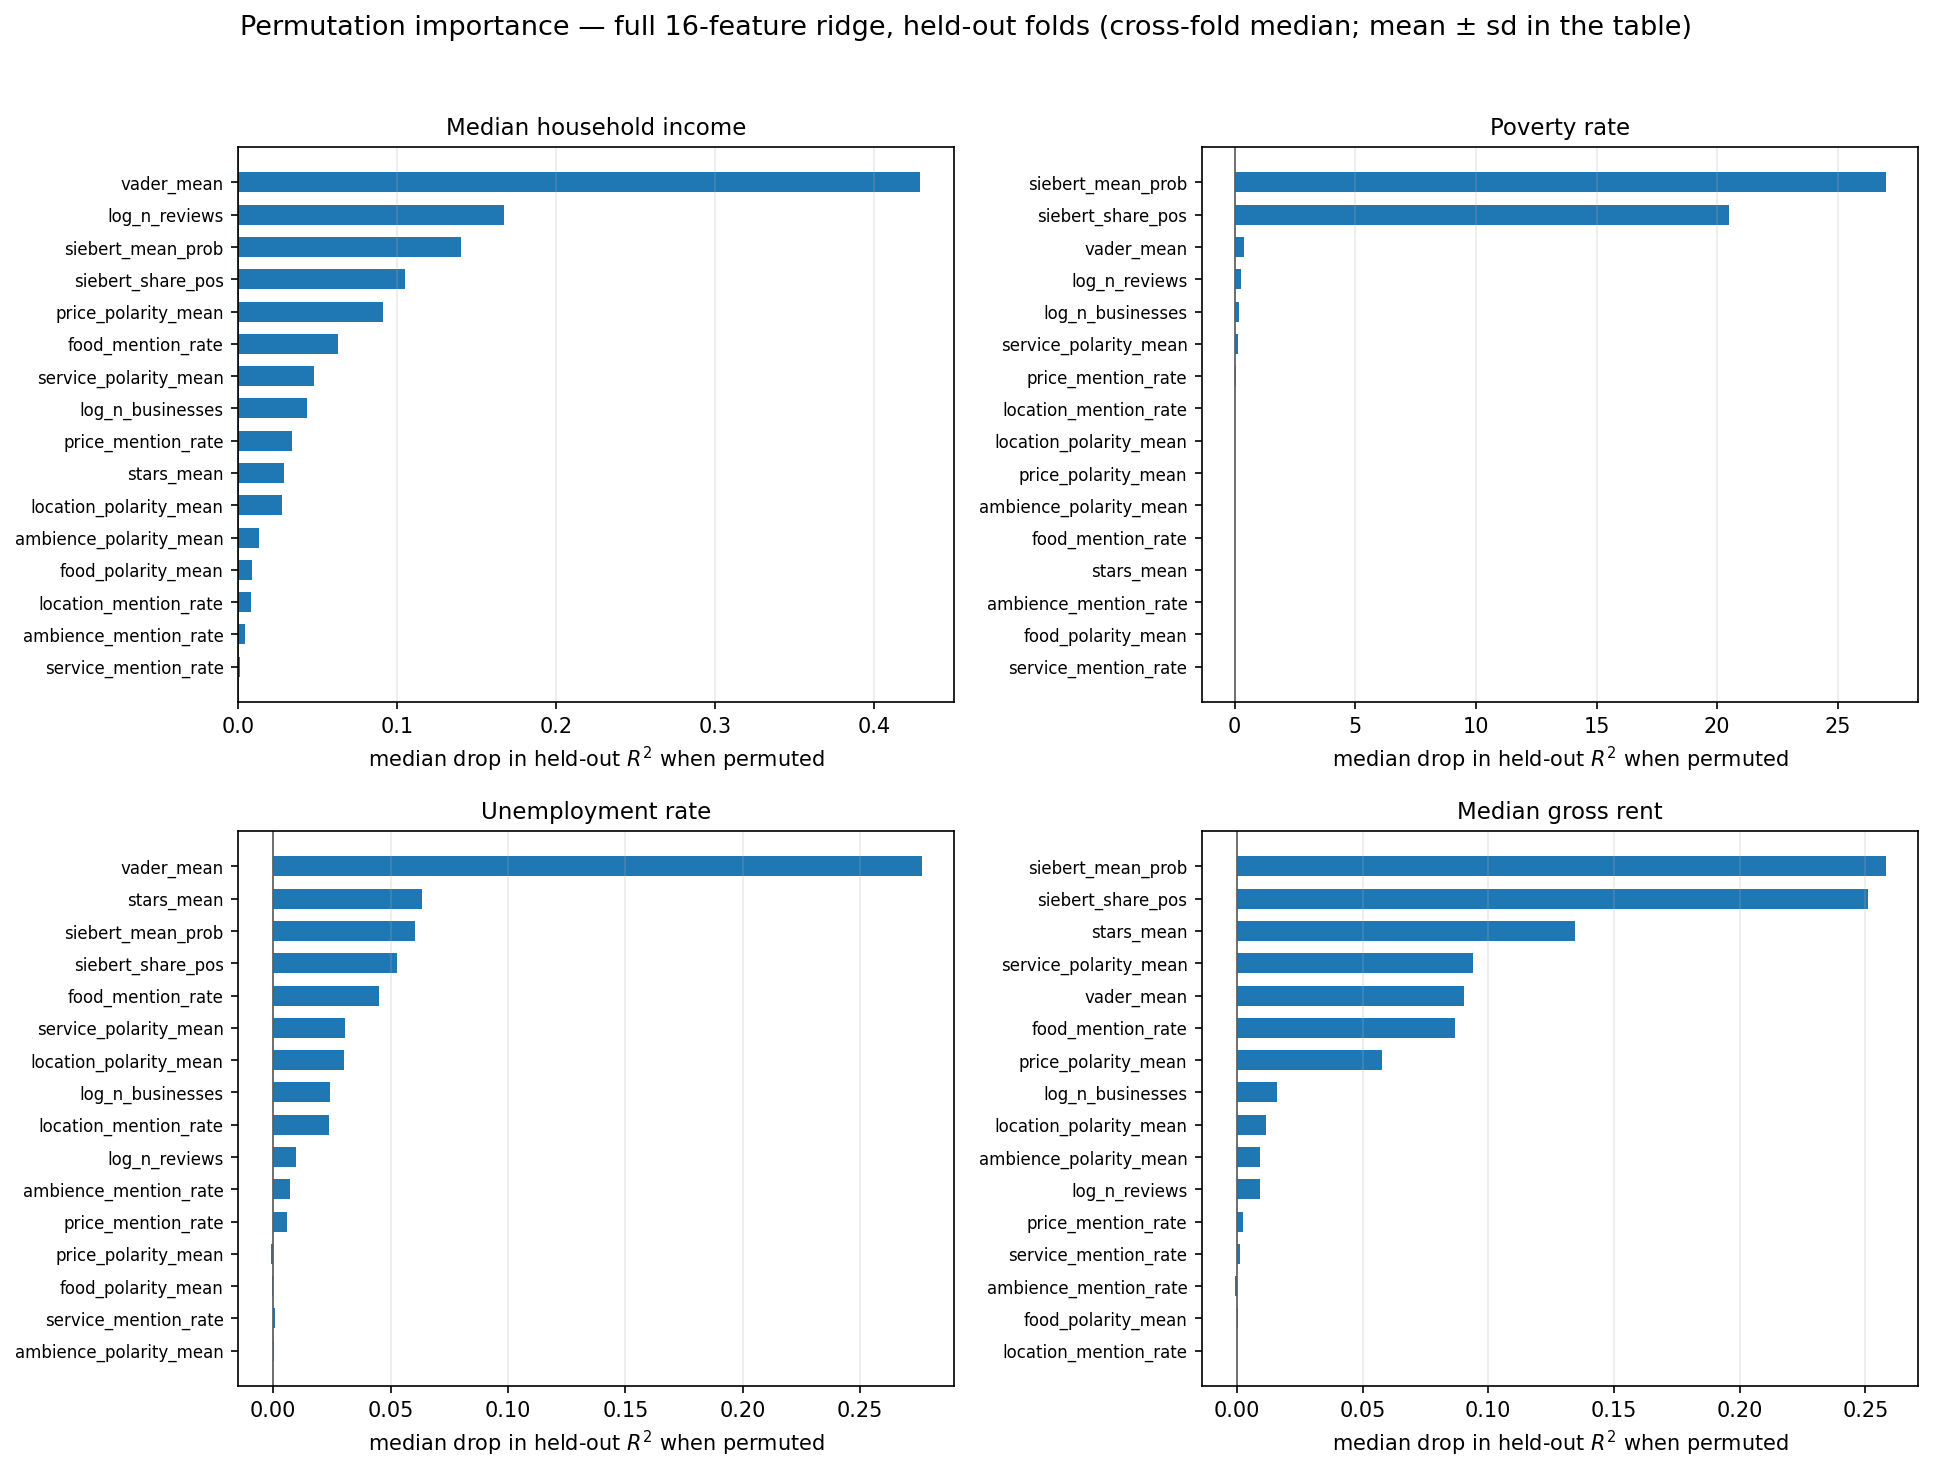

figure -> figures\secondary_ridge_coefficients.png


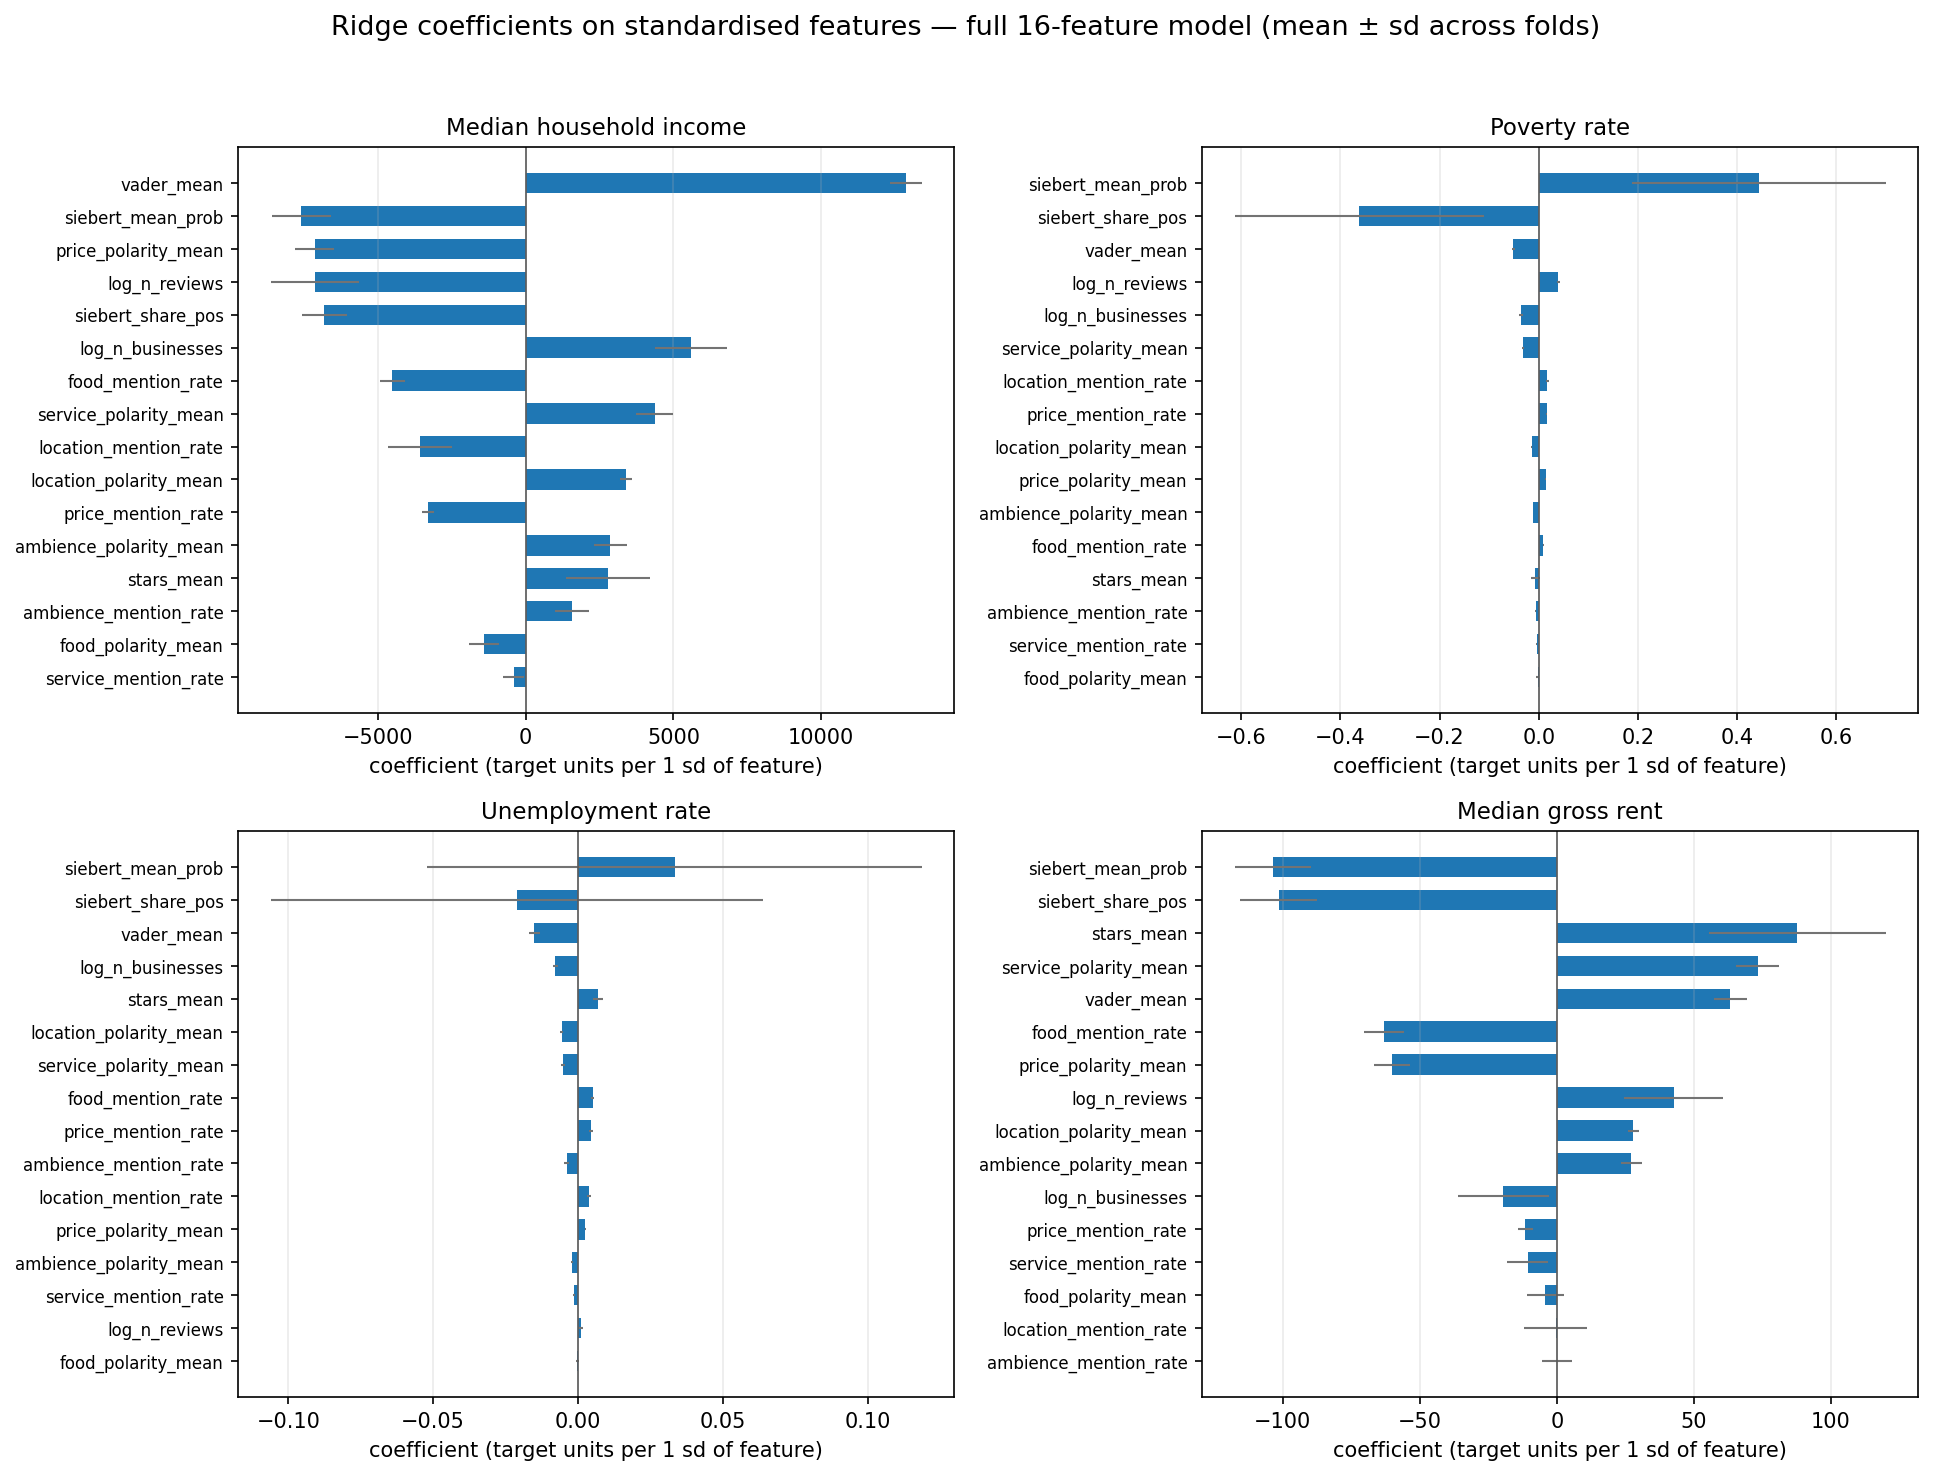

In [15]:
def barh_panels(tbl, value_col, err_col, title, xlabel, fname):
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    for ax, (target, label, _) in zip(axes.ravel(), s6.TARGETS):
        sub = tbl[tbl["target"] == target].copy()
        sub = sub.reindex(sub[value_col].abs().sort_values().index)  # largest magnitude on top
        err = sub[err_col] if err_col else None
        ax.barh(sub["feature"], sub[value_col], xerr=err,
                color=BLUE, height=0.62, error_kw=dict(ecolor="0.45", lw=1))
        ax.axvline(0, color="0.35", lw=0.8)
        ax.set_title(label, fontsize=11)
        ax.set_xlabel(xlabel)
        ax.grid(alpha=0.25, axis="x")
        ax.tick_params(axis="y", labelsize=8)
    fig.suptitle(title, fontsize=13)
    fig.tight_layout(rect=(0, 0, 1, 0.96))
    save_fig(fig, fname)


barh_panels(perm_tbl, "importance_median", None,
            "Permutation importance — full 16-feature ridge, held-out folds "
            "(cross-fold median; mean ± sd in the table)",
            "median drop in held-out $R^2$ when permuted",
            "secondary_permutation_importance.png")
barh_panels(coef_tbl, "coef_mean", "coef_sd",
            "Ridge coefficients on standardised features — full 16-feature model (mean ± sd across folds)",
            "coefficient (target units per 1 sd of feature)",
            "secondary_ridge_coefficients.png")

### 3c — Per-aspect ablation within the ABSA block

All variants sit on the same base (counts + stars + VADER + SiEBERT, i.e. rungs 2–5) and vary only which aspects' `{mention_rate, polarity_mean}` pairs enter: (i) full ABSA — all five aspects, identical to primary rung 6 (asserted; the sanity anchor); (ii) drop-location; (iii) location-only; (iv) drop-{aspect} for each of food, service, price, ambience. Deltas are against full ABSA.

In [16]:
def absa_cols_for(aspects):
    cols = [f"{a}_{stat}" for a in aspects for stat in ("mention_rate", "polarity_mean")]
    return s6.usable_columns(analysis, cols)


OTHER_ASPECTS = [a for a in s6.ASPECTS if a != "location"]
variants = [("full_absa", list(s6.ASPECTS)),
            ("drop_location", OTHER_ASPECTS),
            ("location_only", ["location"])]
variants += [(f"drop_{a}", [x for x in s6.ASPECTS if x != a]) for a in OTHER_ASPECTS]

BASE_COLS = COUNTS_COLS + STARS_COLS + VADER_COLS + SIEBERT_COLS
rows = []
for target, label, _ in s6.TARGETS:
    ref6 = float(ridge.loc[(ridge["target"] == target) & (ridge["rung"] == 6), "r2"].iloc[0])
    full_r2 = None
    for name, aspects in variants:
        cols = BASE_COLS + absa_cols_for(aspects)
        res = s6.spatial_cv(analysis, cols, target, folds, s6.ridge_pipeline)
        if name == "full_absa":
            full_r2 = res["r2"]
            assert np.isclose(full_r2, ref6, rtol=1e-10, atol=1e-12)  # sanity anchor = primary rung 6
        rows.append({"target_label": label, "variant": name,
                     "aspects": "+".join(aspects),
                     "n_absa_features": len(cols) - len(BASE_COLS),
                     "r2": res["r2"], "rmse": res["rmse"],
                     "delta_vs_full_absa": res["r2"] - full_r2})
ablation_tbl = pd.DataFrame(rows)
save_csv(ablation_tbl, "sec3c_aspect_ablation.csv")
ablation_tbl

table  -> data\processed\secondary\sec3c_aspect_ablation.csv


,target_label,variant,aspects,n_absa_features,r2,rmse,delta_vs_full_absa
0,Median household income,full_absa,food+service+price+ambience+location,10,0.063446,30260.326278,0.000000
1,Median household income,drop_location,food+service+price+ambience,8,0.056776,30367.892733,-0.006670
2,Median household income,location_only,location,2,-0.009324,31413.953346,-0.072770
3,Median household income,drop_food,service+price+ambience+location,8,0.062079,30282.413157,-0.001368
4,Median household income,drop_service,food+price+ambience+location,8,0.063324,30262.301713,-0.000122
5,Median household income,drop_price,food+service+ambience+location,8,0.019474,30962.566336,-0.043973
6,Median household income,drop_ambience,food+service+price+location,8,0.058923,30333.316411,-0.004524
7,Poverty rate,full_absa,food+service+price+ambience+location,10,0.133527,0.114125,0.000000
8,Poverty rate,drop_location,food+service+price+ambience,8,0.117667,0.115164,-0.015860
9,Poverty rate,location_only,location,2,0.086648,0.117171,-0.046880


## Additional secondary analysis — review-subsampling curve (post-hoc)

*Specified after the pre-registered secondary list (§3a–3c), and not part of it.* This probes mechanism, not the method ranking: how much of the ABSA rung's out-of-sample signal is limited by per-tract feature noise (few reviews ⇒ noisy tract-level means), as opposed to review volume itself. The method ordering is settled in §1–§3 and is not revisited here.

**Design — within-tract subsampling on the fixed primary design.** The tract set, spatial blocks, folds and outcomes are exactly the shared folds built at the top; nothing about the CV changes at any cap. For each cap $c \in \{10, 20, 50, 100, 200, \text{all}\}$ and each seed $s \in \{0,1,2,3,4\}$ (= `RANDOM_STATE` + $\{0..4\}$) I draw, per tract, a uniform random $\min(n_\text{tract}, c)$ reviews without replacement, rebuild that tract's features from the subsample, and re-score the full rung-6 (ABSA, 16-feature) ridge model with `s6.spatial_cv` on the shared folds, recording the pooled out-of-sample $R^2$ for all four targets.

**Aggregation is delegated, not re-implemented.** Each subsample is aggregated by Stage 5's own `stage5_aggregate.aggregate` (verbose logging silenced). At $c=\text{all}$ the rebuilt features must reproduce the primary `tract_features_2018` and the rung-6 $R^2$ exactly — asserted below; a mismatch would mean the rebuild path is wrong, and the section stops there.

**Feature rule (deliberate).** Every review-averaged feature — `stars_mean`, `vader_mean`, `siebert_share_pos` / `siebert_mean_prob`, and all five aspects' `{mention_rate, polarity_mean}` — is rebuilt from the subsample, but `log_n_reviews` and `log_n_businesses` are held at their true (uncapped) primary values. Capping must not mechanically shrink the volume features: those are the counts rung, and letting them fall with the cap would confound "noisier per-feature means" (the effect I want to isolate) with "fewer reviews/businesses" (a volume effect the counts rung already owns).

**Absent ≠ neutral is preserved.** Polarity means average over mentioning reviews only — never `fillna(0)`. If a tract's subsample contains zero mentions of an aspect, its `{aspect}_polarity_mean` is `NaN`, exactly as in the primary run, and the ridge pipeline's imputer handles it.

In [17]:
import io, contextlib
import pipeline.stage5_aggregate as s5  # Stage 5 aggregation reused verbatim — not re-implemented

SUBSAMPLE_CAPS = [10, 20, 50, 100, 200, "all"]
SUBSAMPLE_SEEDS = [RANDOM_STATE + k for k in (0, 1, 2, 3, 4)]  # -> 0,1,2,3,4

# Review-averaged features = the rung-6 set minus the two (true-valued) log-count features.
REVIEW_AVG_COLS = [c for c in FULL_COLS if c not in COUNTS_COLS]
assert len(REVIEW_AVG_COLS) == 14, REVIEW_AVG_COLS
TARGET_COLS = [t[0] for t in s6.TARGETS]

# Primary rung-6 R2 per target — already computed on the shared folds in §1 (the `ridge` table).
PRIMARY_R6 = {t: float(ridge.loc[(ridge["target"] == t) & (ridge["rung"] == 6), "r2"].iloc[0])
              for t in TARGET_COLS}
# Finite x-position for the 'all' point on the log axis: the median true windowed volume.
MEDIAN_TRUE_VOLUME = float(analysis["n_reviews"].median())

# Build the review-level sampling frame once (windowed 2014-2018, analysis tracts only).
_corpus = pd.read_parquet(s5.CORPUS_PARQUET,
                          columns=["review_id", "business_id", "stars", "date"])
_biz = pd.read_parquet(config.INTERIM_DIR / f"businesses_with_tract_{ACS_YEAR}.parquet",
                       columns=["business_id", "tract_geoid"])
_start, _end = config.REVIEW_WINDOWS[ACS_YEAR]
base = _corpus.merge(_biz, on="business_id", how="inner", validate="m:1")
base = base[base["date"].dt.year.between(_start, _end)]
base = base[base["tract_geoid"].isin(set(analysis_ids))].reset_index(drop=True)
del _corpus
assert base["tract_geoid"].nunique() == len(analysis_ids)

# Scores loaded once via Stage 5's own loader, subset to the base reviews to keep the joins light.
with contextlib.redirect_stdout(io.StringIO()):
    _scores_full = s5.load_scores(smoke=False)
_base_ids = set(base["review_id"])
SCORES = {m: (df[df["review_id"].isin(_base_ids)].reset_index(drop=True) if df is not None else None)
          for m, df in _scores_full.items()}
del _scores_full
print(f"sampling frame: {len(base):,} windowed reviews across {base['tract_geoid'].nunique():,} "
      f"analysis tracts | median true volume = {MEDIAN_TRUE_VOLUME:g}")

_CORPUS_COLS = ["review_id", "business_id", "stars", "date"]  # cols aggregate() expects


def rebuild_features(sampled):
    """Tract features for a subsample, via Stage 5's aggregate (its logging silenced).
    aggregate() re-derives tract_geoid from the biz table, so we pass the corpus columns only."""
    with contextlib.redirect_stdout(io.StringIO()):
        return s5.aggregate(ACS_YEAR, sampled[_CORPUS_COLS], SCORES)


def model_frame(feats):
    """Rung-6 model frame: TRUE log-count features + targets from `analysis`; the 14
    review-averaged features from the subsample rebuild."""
    left = analysis[["tract_geoid", *COUNTS_COLS, *TARGET_COLS]]
    frame = left.merge(feats[["tract_geoid", *REVIEW_AVG_COLS]], on="tract_geoid", validate="1:1")
    assert len(frame) == len(analysis)
    return frame


def rung6_r2(frame):
    return {t: s6.spatial_cv(frame, FULL_COLS, t, folds, s6.ridge_pipeline)["r2"] for t in TARGET_COLS}


def subsample(cap, seed):
    """Uniform SRS of min(n, cap) reviews per tract, WITHOUT replacement: one global shuffle,
    then keep each tract's first `cap` rows via cumcount (fast, and equivalent to per-tract SRS)."""
    sh = base.sample(frac=1.0, random_state=seed)
    return sh[sh.groupby("tract_geoid").cumcount() < cap]


# Verification at cap='all': the rebuild must reproduce the primary run exactly.
feats_all = rebuild_features(base)  # unshuffled -> same within-tract summation order as the primary
_chk = analysis[["tract_geoid", *REVIEW_AVG_COLS]].merge(
    feats_all[["tract_geoid", *REVIEW_AVG_COLS]], on="tract_geoid", suffixes=("_p", "_r"))
assert len(_chk) == len(analysis)
_max_abs = 0.0
for c in REVIEW_AVG_COLS:
    a, b = _chk[f"{c}_p"], _chk[f"{c}_r"]
    both_nan = a.isna() & b.isna()
    assert (both_nan | np.isclose(a, b, rtol=1e-9, atol=1e-12)).all(), f"feature mismatch: {c}"
    _max_abs = max(_max_abs, float((a - b).abs()[~both_nan].max()) if (~both_nan).any() else 0.0)
R6_ALL = rung6_r2(model_frame(feats_all))
for t in TARGET_COLS:
    assert np.isclose(R6_ALL[t], PRIMARY_R6[t], rtol=1e-10, atol=1e-12), (t, R6_ALL[t], PRIMARY_R6[t])
print(f"VERIFIED cap='all' reproduces the primary run to machine precision — "
      f"max |dfeature| = {_max_abs:.2e}, "
      f"max |dR2| = {max(abs(R6_ALL[t] - PRIMARY_R6[t]) for t in TARGET_COLS):.2e}")

sampling frame: 3,625,735 windowed reviews across 3,444 analysis tracts | median true volume = 352.5


VERIFIED cap='all' reproduces the primary run to machine precision — max |dfeature| = 0.00e+00, max |dR2| = 0.00e+00


  cap =   10 done


  cap =   20 done


  cap =   50 done


  cap =  100 done


  cap =  200 done
  cap =  all done
table  -> data\processed\secondary\sec6_subsampling_curve.csv


figure -> figures\secondary_subsampling_curve.png


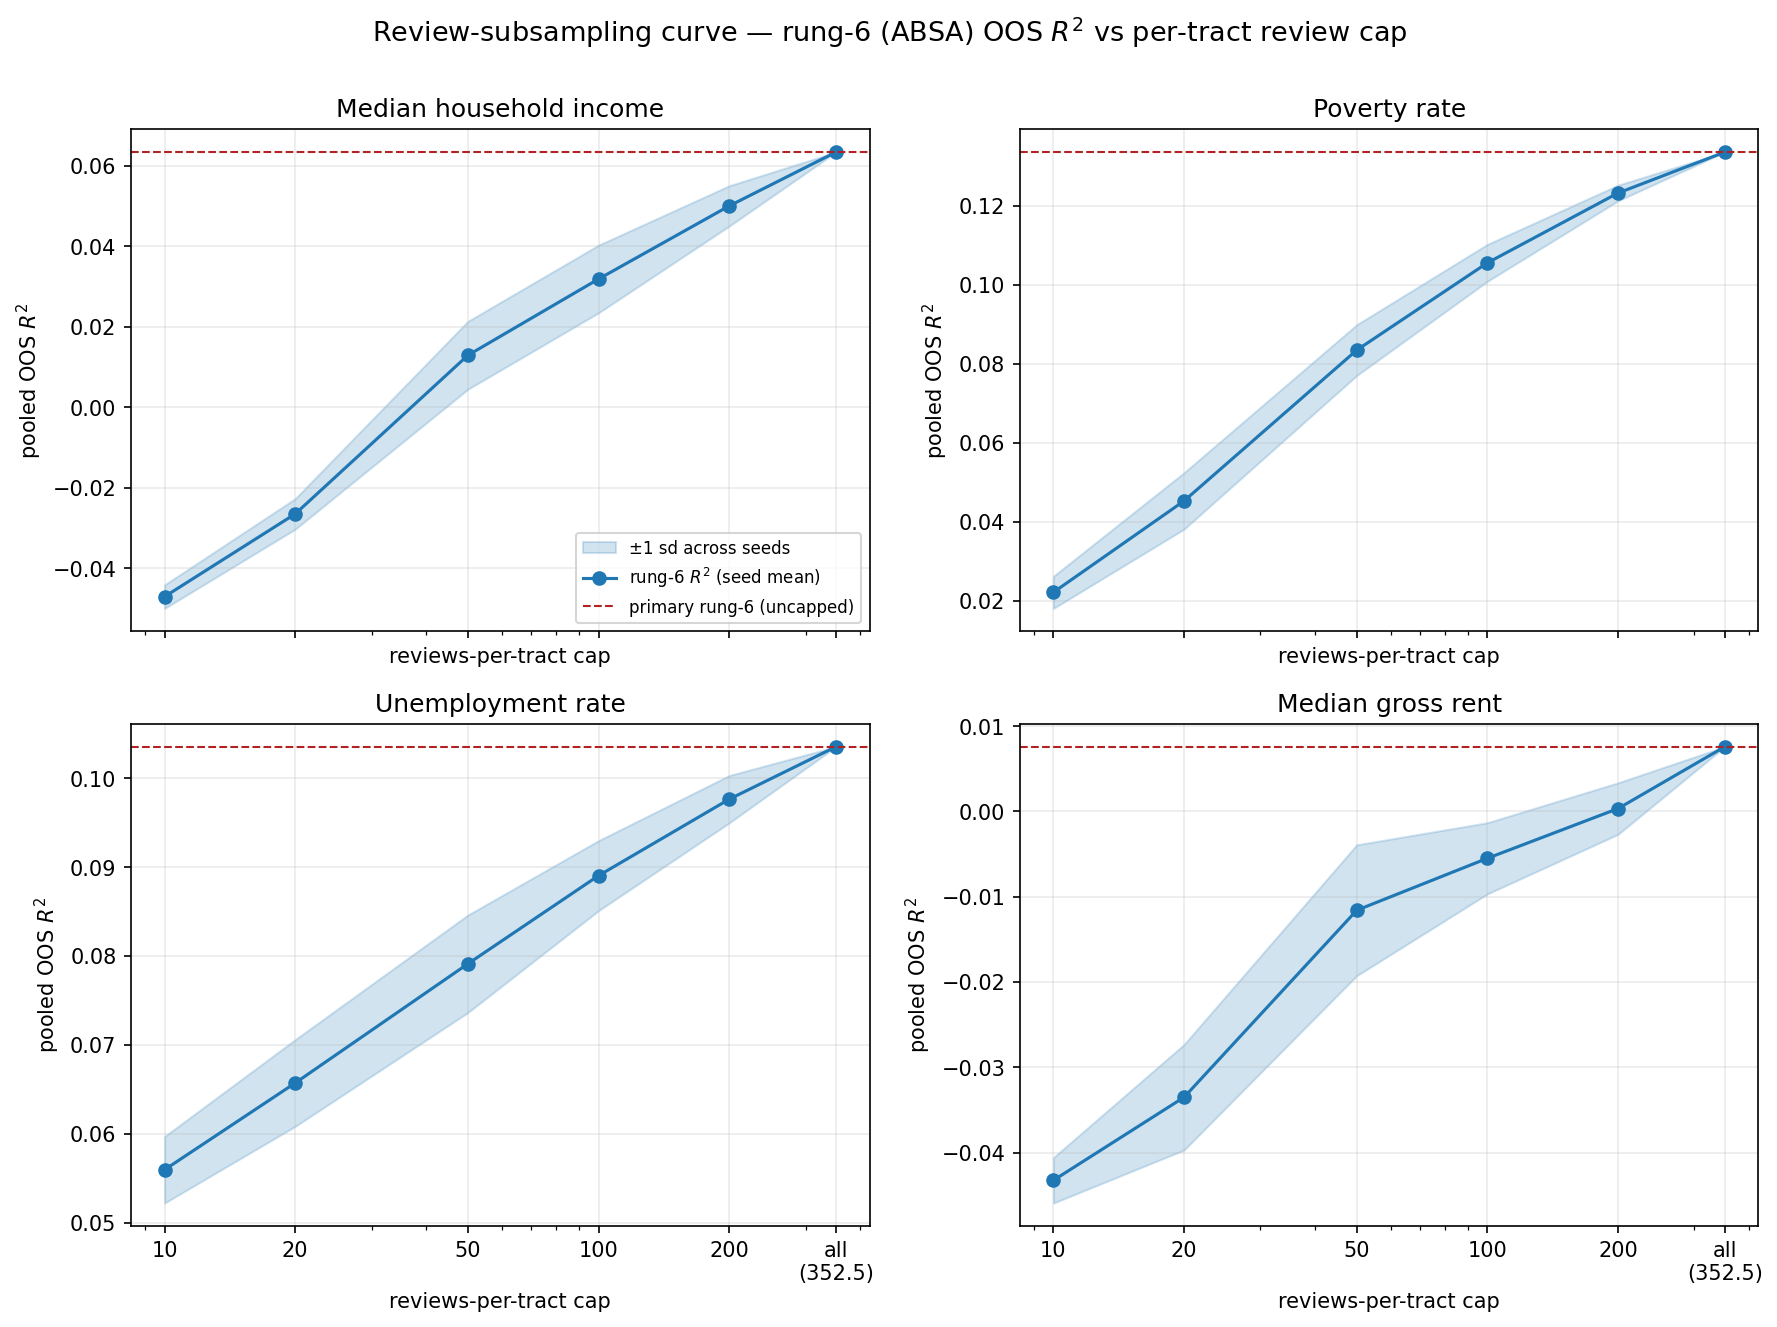

,cap,target,mean_r2,sd_r2,n_seeds,cap_x,target_label,primary_r6_r2
0,10,median_gross_rent,-0.043248,0.002667,5,10.0,Median gross rent,0.007596
1,20,median_gross_rent,-0.033510,0.006186,5,20.0,Median gross rent,0.007596
2,50,median_gross_rent,-0.011582,0.007673,5,50.0,Median gross rent,0.007596
3,100,median_gross_rent,-0.005490,0.004176,5,100.0,Median gross rent,0.007596
4,200,median_gross_rent,0.000341,0.003020,5,200.0,Median gross rent,0.007596
5,all,median_gross_rent,0.007596,0.000000,5,352.5,Median gross rent,0.007596
6,10,median_household_income,-0.047016,0.002927,5,10.0,Median household income,0.063446
7,20,median_household_income,-0.026458,0.003797,5,20.0,Median household income,0.063446
8,50,median_household_income,0.012959,0.008440,5,50.0,Median household income,0.063446
9,100,median_household_income,0.031910,0.008407,5,100.0,Median household income,0.063446


In [18]:
# Sweep the caps x seeds, recording pooled OOS R2 for the rung-6 (ABSA) model each time.
records = []
for cap in SUBSAMPLE_CAPS:
    if cap == "all":
        # min(n, all) = n, so every seed rebuilds the full (primary) frame -> seed-invariant.
        for seed in SUBSAMPLE_SEEDS:
            records += [{"cap": "all", "seed": seed, "target": t, "r2": R6_ALL[t]} for t in TARGET_COLS]
    else:
        for seed in SUBSAMPLE_SEEDS:
            r6 = rung6_r2(model_frame(rebuild_features(subsample(cap, seed))))
            records += [{"cap": str(cap), "seed": seed, "target": t, "r2": r6[t]} for t in TARGET_COLS]
    print(f"  cap = {str(cap):>4} done")

_rec = pd.DataFrame(records)
_label = {t[0]: t[1] for t in s6.TARGETS}
_cap_x = {"10": 10, "20": 20, "50": 50, "100": 100, "200": 200, "all": MEDIAN_TRUE_VOLUME}
subsampling_tbl = (_rec.groupby(["cap", "target"])
                   .agg(mean_r2=("r2", "mean"), sd_r2=("r2", "std"), n_seeds=("r2", "size"))
                   .reset_index())
subsampling_tbl["cap_x"] = subsampling_tbl["cap"].map(_cap_x)
subsampling_tbl["target_label"] = subsampling_tbl["target"].map(_label)
subsampling_tbl["primary_r6_r2"] = subsampling_tbl["target"].map(PRIMARY_R6)
subsampling_tbl = subsampling_tbl.sort_values(["target", "cap_x"]).reset_index(drop=True)
save_csv(subsampling_tbl, "sec6_subsampling_curve.csv")

# Figure: 2x2 panels (one per target); x = per-tract cap (log), 'all' at the median volume.
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=True)
_order = [10, 20, 50, 100, 200, MEDIAN_TRUE_VOLUME]
for ax, (target, label, _) in zip(axes.ravel(), s6.TARGETS):
    sub = subsampling_tbl[subsampling_tbl["target"] == target].sort_values("cap_x")
    x = sub["cap_x"].to_numpy()
    m = sub["mean_r2"].to_numpy()
    sd = sub["sd_r2"].fillna(0.0).to_numpy()
    ax.fill_between(x, m - sd, m + sd, color=BLUE, alpha=0.2, label="±1 sd across seeds")
    ax.plot(x, m, "-o", color=BLUE, label="rung-6 $R^2$ (seed mean)")
    ax.axhline(PRIMARY_R6[target], color="firebrick", ls="--", lw=1, label="primary rung-6 (uncapped)")
    ax.set_xscale("log")
    ax.set_xticks(_order)
    ax.set_xticklabels(["10", "20", "50", "100", "200", f"all\n({MEDIAN_TRUE_VOLUME:g})"])
    ax.set_title(label)
    ax.set_ylabel("pooled OOS $R^2$")
    ax.set_xlabel("reviews-per-tract cap")
    ax.grid(alpha=0.25)
axes.ravel()[0].legend(fontsize=8, loc="best")
fig.suptitle("Review-subsampling curve — rung-6 (ABSA) OOS $R^2$ vs per-tract review cap", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.98))
save_fig(fig, "secondary_subsampling_curve.png")
subsampling_tbl

**Reading the curve.** In each panel the dashed line is the primary (uncapped) rung-6 $R^2$; the solid curve rises monotonically toward it as the per-tract cap grows and lands exactly on it at `all` (the verified anchor). This isolates within-tract feature noise: with few reviews per tract the aggregated ABSA features are noisy estimates and the model recovers less signal; the gap closes purely by averaging more reviews, with the volume features (`log_n_*`) held fixed. The `all` point is plotted at the median true windowed volume across the analysis tracts — a finite $x$ on the log axis; ≈ 352 here, not a round number but the empirical median, printed above.

**Caveat.** A within-sample noise-reduction curve over the observed review volumes. It says nothing about volumes beyond those observed and does not license extrapolation past the uncapped design — the rightmost point is the real data, not a projection.

## Section 4 — Threshold sensitivity (READ-ONLY)

Loads the existing `ladder_results_minrev{10,20,50}.csv` sweep outputs — nothing is re-run — and consolidates them: per target × threshold, the best ridge rung, its R², the stars and ABSA rungs' R², and the text-over-stars delta (rung 6 − rung 3).

Caveat: cross-threshold values are not paired — each threshold has its own tract set and its own rebuilt folds — so read movement across thresholds as trend only, not as a paired comparison.

In [19]:
rows = []
for n in (10, 20, 50):
    path = s6.results_csv(smoke=False, min_reviews=n)
    sweep = pd.read_csv(path)
    sweep_ridge = sweep[sweep["predictor"] == "ridge"]
    for target, label, _ in s6.TARGETS:
        sub = sweep_ridge[sweep_ridge["target"] == target].set_index("rung")
        best = sub["r2"].idxmax()
        rows.append({
            "min_reviews": n, "target_label": label,
            "n_test_tracts": int(sub.loc[6, "n_test_tracts"]),
            "best_rung": sub.loc[best, "rung_name"],
            "best_rung_r2": sub.loc[best, "r2"],
            "stars_r2": sub.loc[3, "r2"],
            "absa_r2": sub.loc[6, "r2"],
            "text_over_stars_delta": sub.loc[6, "r2"] - sub.loc[3, "r2"],
        })
threshold_tbl = pd.DataFrame(rows).sort_values(["target_label", "min_reviews"]).reset_index(drop=True)
save_csv(threshold_tbl, "sec4_threshold_sensitivity.csv")
threshold_tbl

table  -> data\processed\secondary\sec4_threshold_sensitivity.csv


,min_reviews,target_label,n_test_tracts,best_rung,best_rung_r2,stars_r2,absa_r2,text_over_stars_delta
0,10,Median gross rent,3528,absa,0.004490,-0.051885,0.004490,0.056375
1,20,Median gross rent,3358,absa,0.007596,-0.054552,0.007596,0.062148
2,50,Median gross rent,3039,absa,0.003527,-0.056987,0.003527,0.060514
3,10,Median household income,3598,absa,0.058799,-0.071037,0.058799,0.129837
4,20,Median household income,3418,absa,0.063446,-0.080596,0.063446,0.144042
5,50,Median household income,3089,absa,0.069227,-0.090775,0.069227,0.160002
6,10,Poverty rate,3606,absa,0.115291,-0.002532,0.115291,0.117823
7,20,Poverty rate,3425,absa,0.133527,-0.004416,0.133527,0.137943
8,50,Poverty rate,3094,absa,0.133888,-0.012535,0.133888,0.146423
9,10,Unemployment rate,3606,absa,0.092876,0.039449,0.092876,0.053427


## Section 5 — EXPLORATORY — not pre-specified, not for headline reporting

Cheap diagnostics on the headline ABSA rung and the fold structure. Nothing here feeds the primary results.

figure -> figures\secondary_absa_pred_vs_actual.png


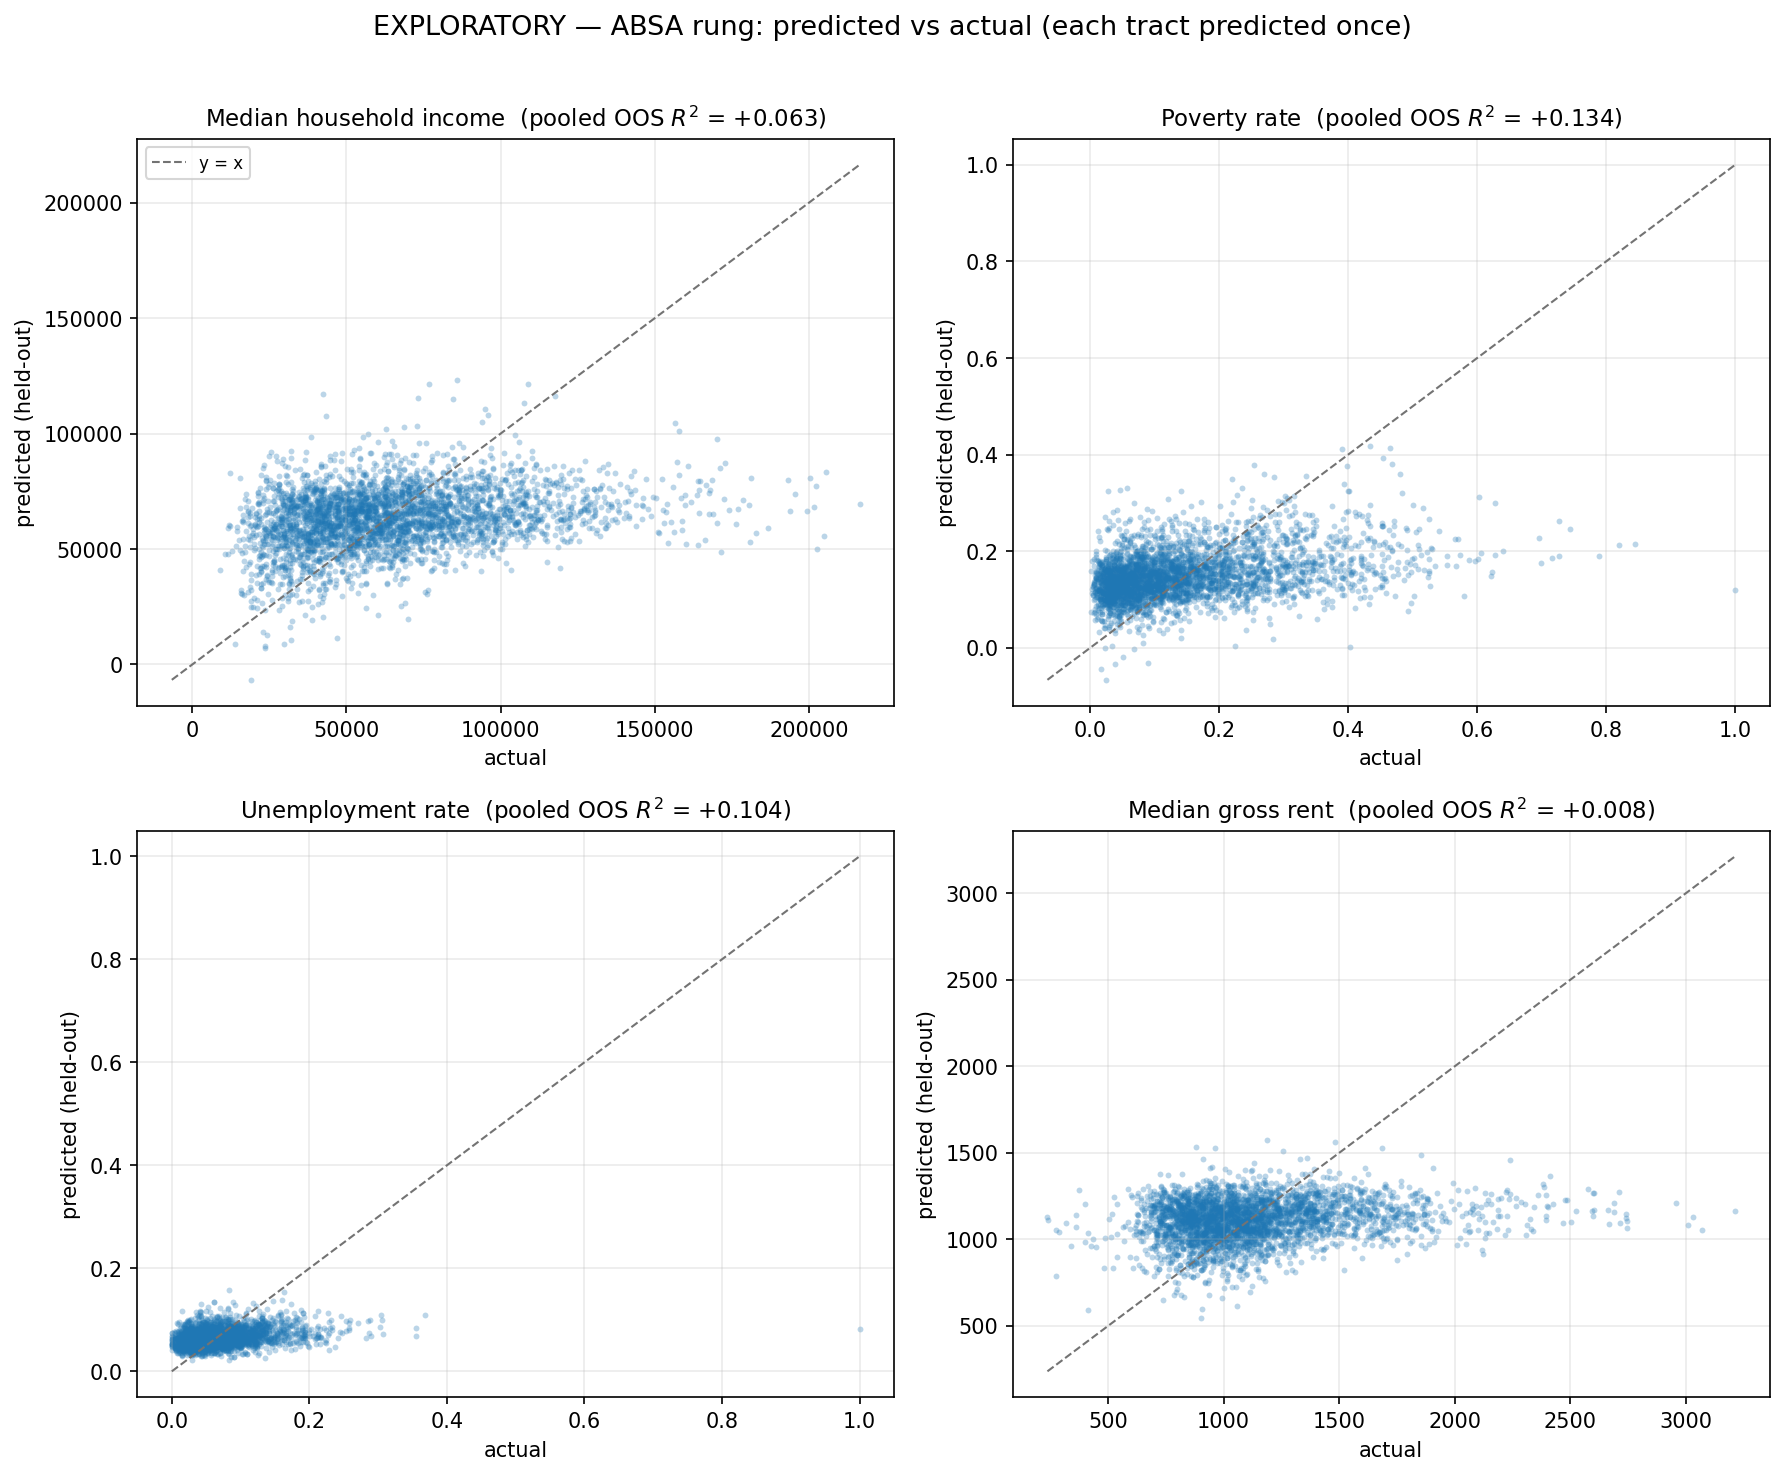

WindowsPath('C:/Users/joein/OneDrive/one drive/QMUL/Dissertation/Code/figures/secondary_absa_pred_vs_actual.png')

In [20]:
# Predicted vs actual, ABSA rung (rung 6), pooled held-out predictions.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (target, label, units) in zip(axes.ravel(), s6.TARGETS):
    p = absa_preds[target]
    ax.scatter(p["y_true"], p["y_pred"], s=8, alpha=0.3, color=BLUE, linewidths=0)
    lo = float(min(p["y_true"].min(), p["y_pred"].min()))
    hi = float(max(p["y_true"].max(), p["y_pred"].max()))
    ax.plot([lo, hi], [lo, hi], ls="--", color="0.45", lw=1, label="y = x")
    ax.set_title(f"{label}  (pooled OOS $R^2$ = {r2_score(p['y_true'], p['y_pred']):+.3f})",
                 fontsize=11)
    ax.set_xlabel("actual")
    ax.set_ylabel("predicted (held-out)")
    ax.grid(alpha=0.25)
axes.ravel()[0].legend(fontsize=8, loc="best")
fig.suptitle("EXPLORATORY — ABSA rung: predicted vs actual (each tract predicted once)", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.97))
save_fig(fig, "secondary_absa_pred_vs_actual.png")

figure -> figures\secondary_fold_r2_by_rung.png


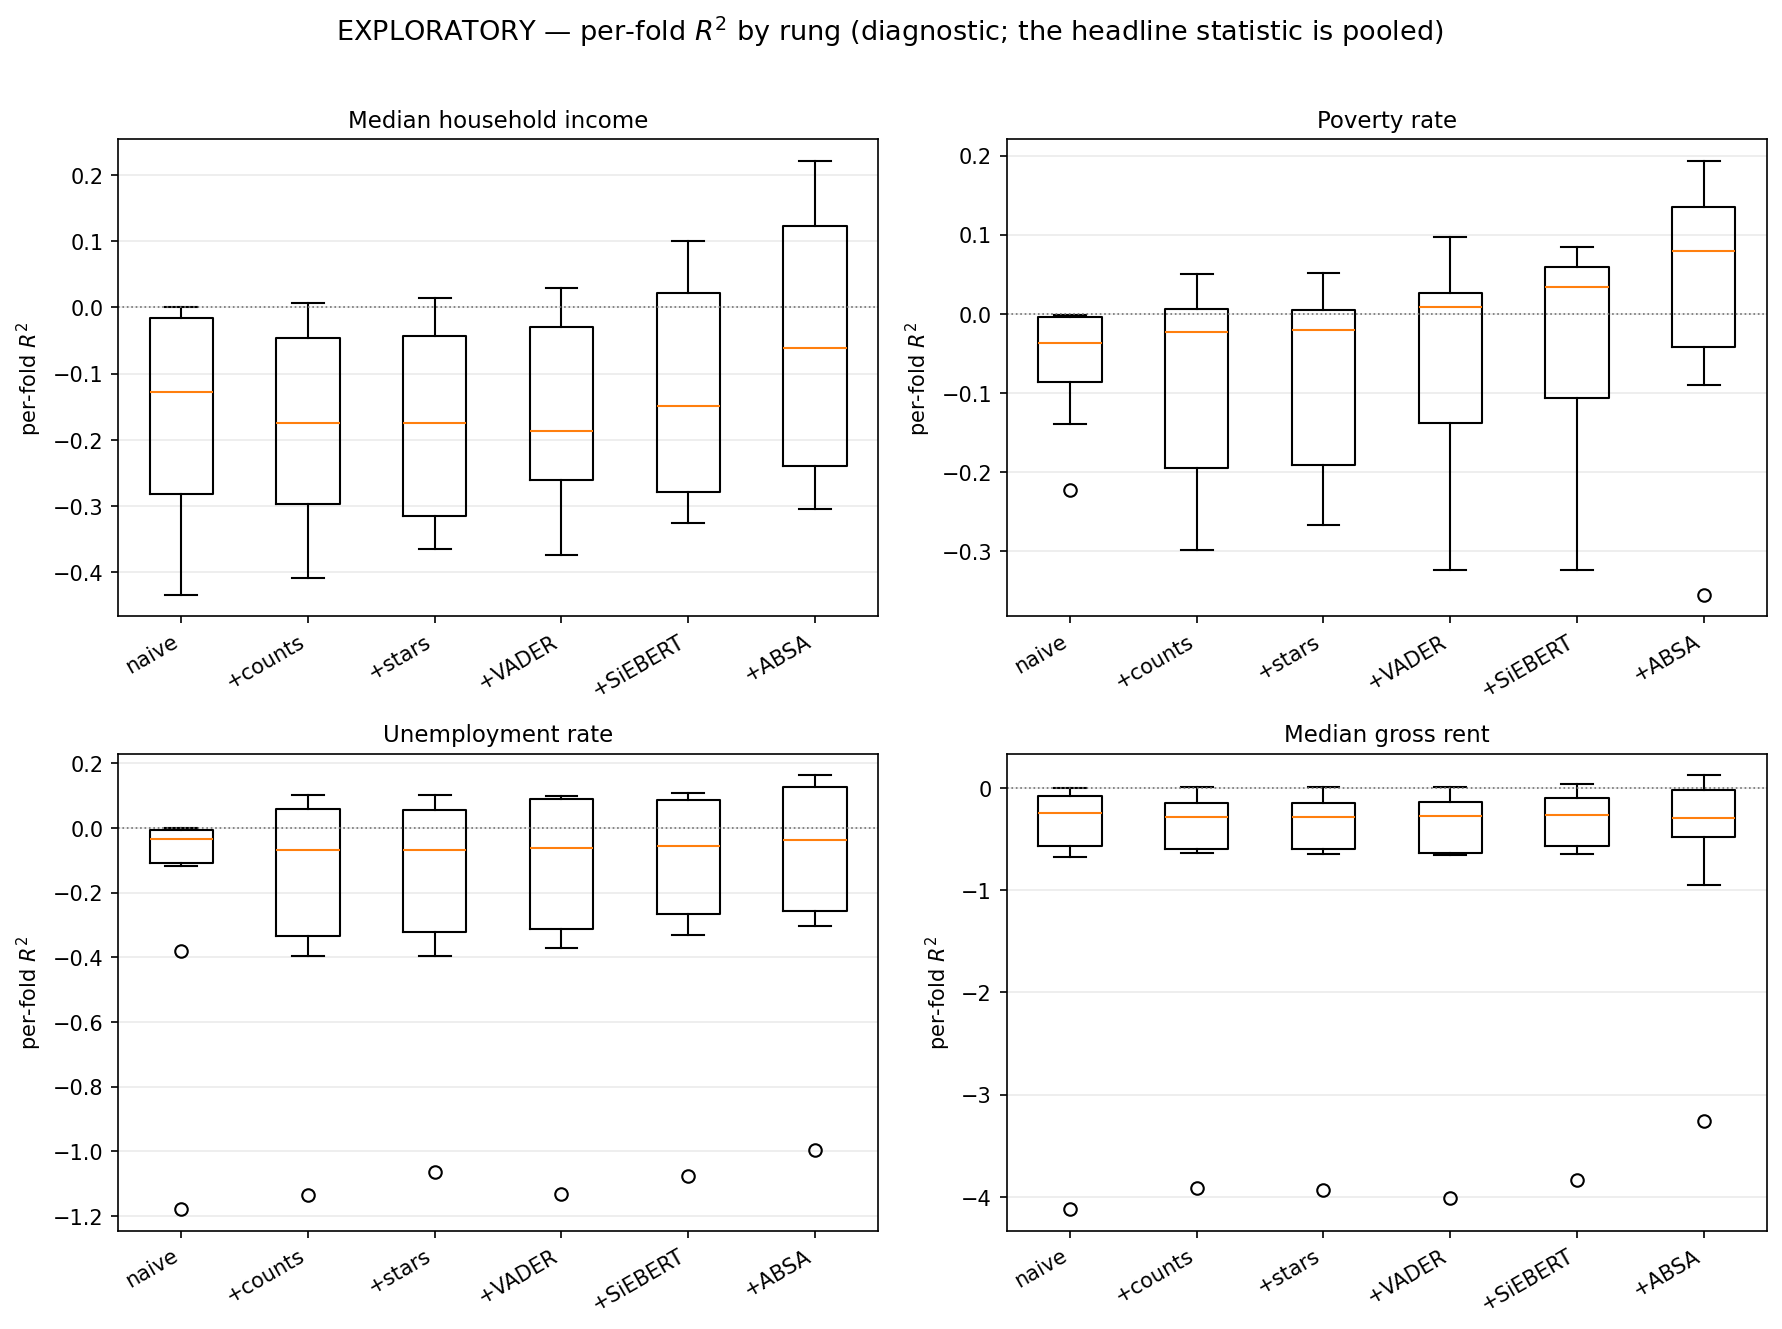

WindowsPath('C:/Users/joein/OneDrive/one drive/QMUL/Dissertation/Code/figures/secondary_fold_r2_by_rung.png')

In [21]:
# Per-fold R2 distribution across the ridge rungs (parsed from the recomputed ladder table).
def parse_fold_r2(s):
    return [float(v) for v in str(s).split(";") if v and v != "nan"]


fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, (target, label, _) in zip(axes.ravel(), s6.TARGETS):
    sub = ridge[ridge["target"] == target].sort_values("rung")
    data = [parse_fold_r2(s) for s in sub["fold_r2"]]
    ax.boxplot(data)
    ax.set_xticks(range(1, len(data) + 1))
    ax.set_xticklabels([s6.RUNG_TICK[r] for r in sub["rung"]], rotation=30, ha="right")
    ax.axhline(0, color="0.45", lw=0.8, ls=":")
    ax.set_title(label, fontsize=11)
    ax.set_ylabel("per-fold $R^2$")
    ax.grid(alpha=0.25, axis="y")
fig.suptitle("EXPLORATORY — per-fold $R^2$ by rung (diagnostic; the headline statistic is pooled)",
             fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.97))
save_fig(fig, "secondary_fold_r2_by_rung.png")

figure -> figures\secondary_absa_residual_vs_nreviews.png


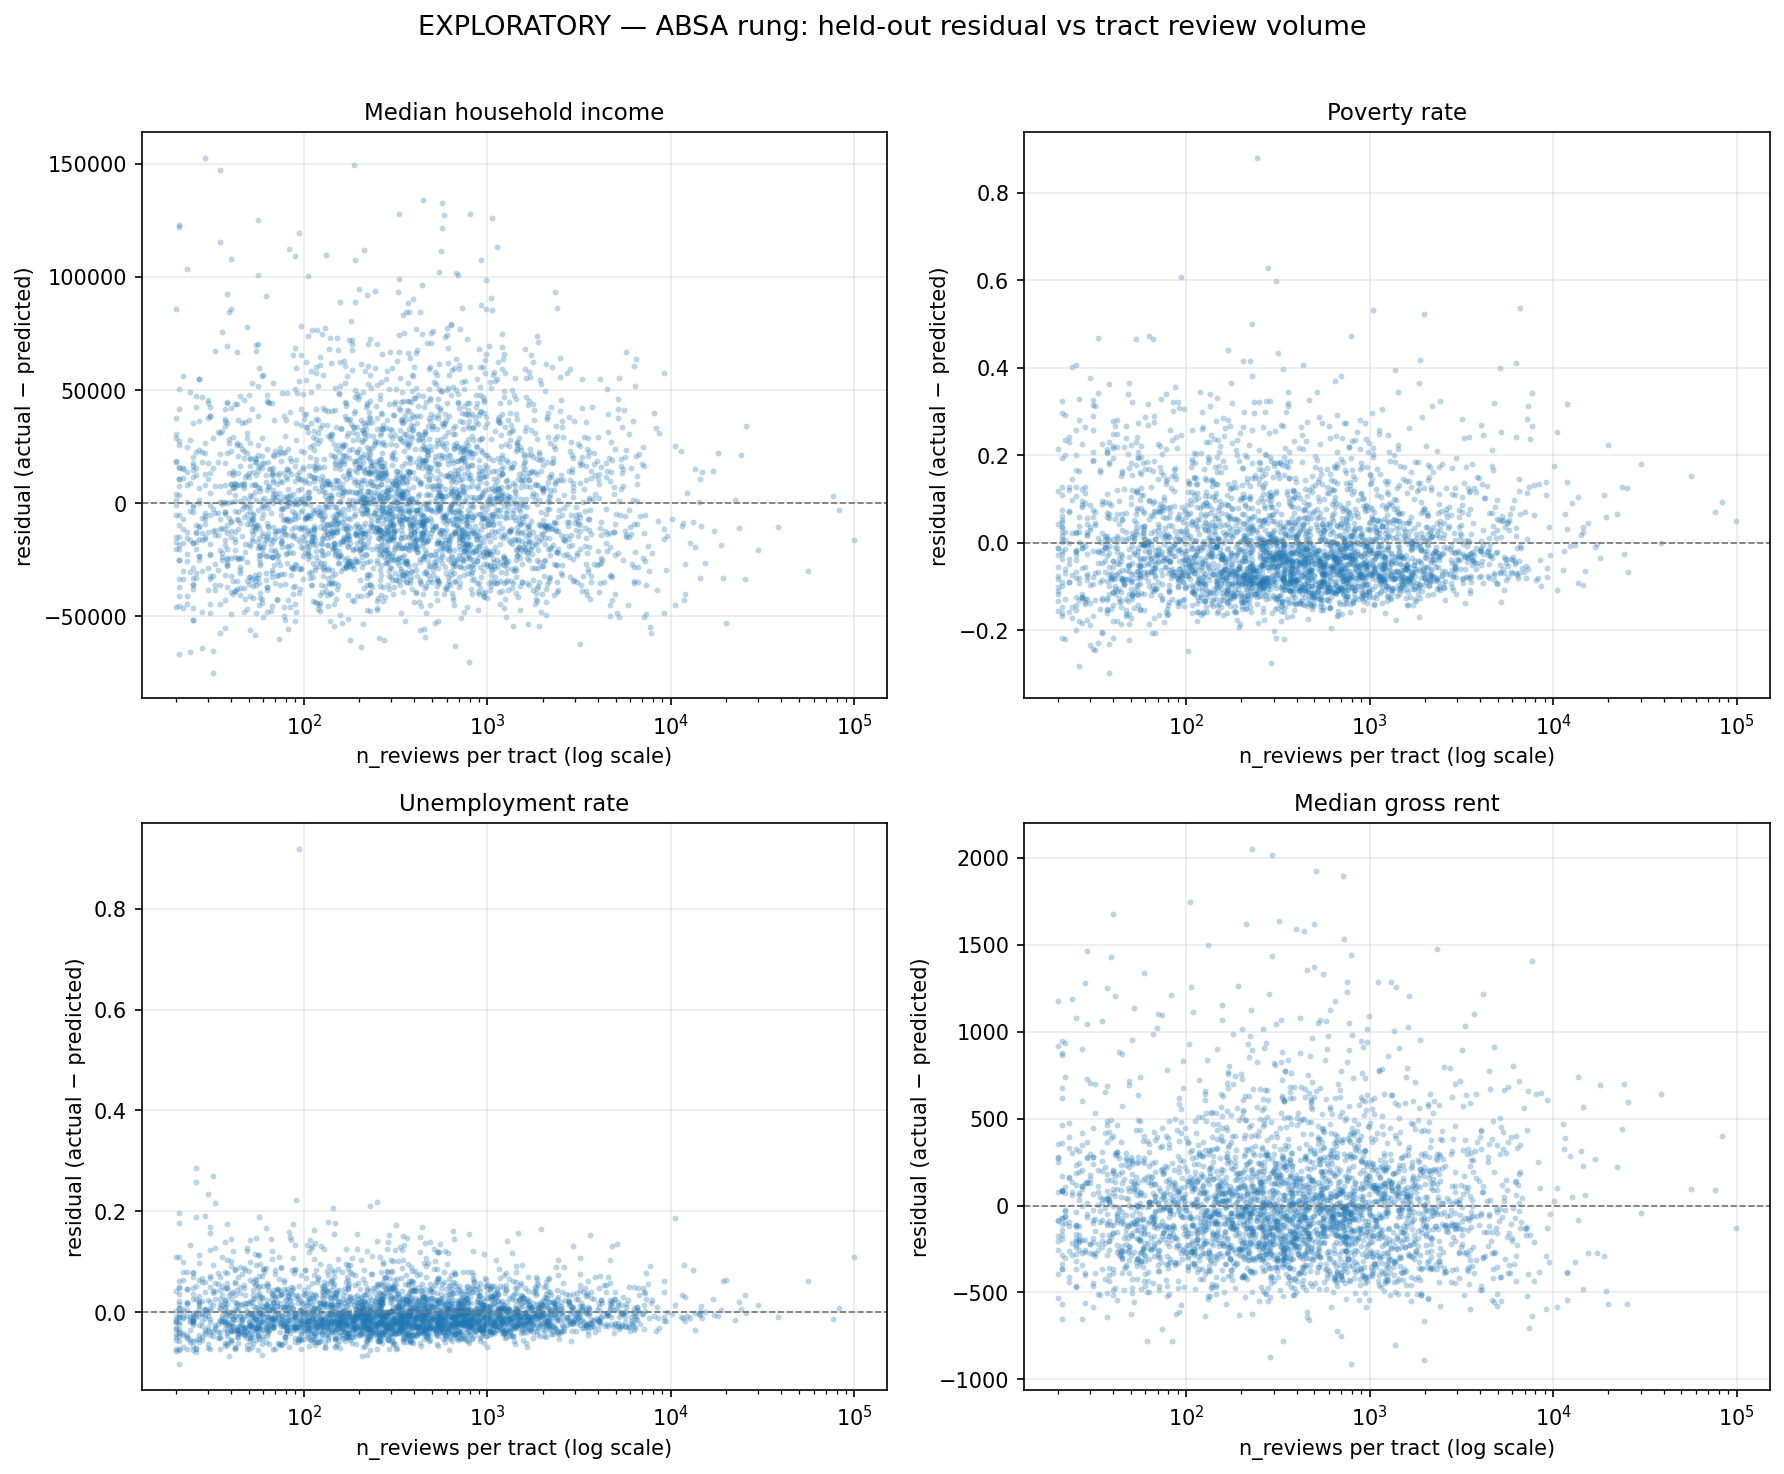

WindowsPath('C:/Users/joein/OneDrive/one drive/QMUL/Dissertation/Code/figures/secondary_absa_residual_vs_nreviews.png')

In [22]:
# Residual vs tract review volume, ABSA rung.
n_reviews_of = analysis.set_index("tract_geoid")["n_reviews"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (target, label, _) in zip(axes.ravel(), s6.TARGETS):
    p = absa_preds[target]
    resid = p["y_true"] - p["y_pred"]
    ax.scatter(n_reviews_of.loc[p["tract_geoid"]].to_numpy(), resid,
               s=8, alpha=0.3, color=BLUE, linewidths=0)
    ax.axhline(0, color="0.45", lw=0.8, ls="--")
    ax.set_xscale("log")
    ax.set_title(label, fontsize=11)
    ax.set_xlabel("n_reviews per tract (log scale)")
    ax.set_ylabel("residual (actual − predicted)")
    ax.grid(alpha=0.25)
fig.suptitle("EXPLORATORY — ABSA rung: held-out residual vs tract review volume", fontsize=13)
fig.tight_layout(rect=(0, 0, 1, 0.97))
save_fig(fig, "secondary_absa_residual_vs_nreviews.png")

## Manifest

Every file this notebook wrote, plus a check that the primary artefacts were not modified (mtimes unchanged since the setup cell).

In [23]:
print(f"{len(WRITTEN)} files written by this notebook:\n")
for p in WRITTEN:
    print(f"    {p.relative_to(config.PROJECT_ROOT)}")

for p, mtime in _primary_mtimes.items():
    assert p.stat().st_mtime_ns == mtime, f"primary artefact modified: {p}"
print("\nprimary artefacts verified untouched (mtime unchanged):")
for p in _primary_mtimes:
    print(f"    {p.relative_to(config.PROJECT_ROOT)}")

21 files written by this notebook:

    data\processed\secondary\sec1_check1_naive_floor.csv
    data\processed\secondary\sec1_check2_full_ladder.csv
    data\processed\secondary\sec1_check3_text_over_stars.csv
    data\processed\secondary\sec1_check4_analysis_n.csv
    data\processed\secondary\sec1_check5_rf_vs_ridge.csv
    data\processed\secondary\sec2_metro_tract_counts.csv
    data\processed\secondary\sec2_block_metro_purity.csv
    data\processed\secondary\sec2_absa_per_metro.csv
    data\processed\secondary\sec2_absa_per_fold_r2.csv
    data\processed\secondary\sec3a_solo_over_stars.csv
    data\processed\secondary\sec3b_ridge_coefficients.csv
    data\processed\secondary\sec3b_permutation_importance.csv
    figures\secondary_permutation_importance.png
    figures\secondary_ridge_coefficients.png
    data\processed\secondary\sec3c_aspect_ablation.csv
    data\processed\secondary\sec6_subsampling_curve.csv
    figures\secondary_subsampling_curve.png
    data\processed\secondary\s